# Simulation FEM 1D en régime stationnaire

Dans cette première approche, on étudie un problème de conduction thermique unidimensionnelle en régime stationnaire. On néglige tout terme source et on ne considère pas de pertes latérales. L’équation différentielle à résoudre est donc :

$$
\frac{d^2T}{dx^2}=0
$$

avec des températures imposées aux deux extrémités :

$$
T(0)=T_{\mathrm{inf}}
$$

$$
T(L)=T_{\mathrm{sup}}
$$

L’objectif de ce notebook est de résoudre ce problème avec la méthode des éléments finis, en utilisant des éléments linéaires de Lagrange, puis de comparer la solution numérique avec la solution analytique exacte.

1. Importation des librairies

Dans ce bloc, on importe les librairies nécessaires pour le calcul numérique et la visualisation des résultats. La librairie `numpy` est utilisée pour construire les matrices et résoudre les systèmes linéaires. La librairie `pandas` sert à organiser les résultats sous forme de tableaux, et `matplotlib` permet de tracer les profils de température.

In [ ]:
port numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

## 2. Définition du problème physique et du maillage

On définit ici la longueur de l’échantillon, les températures imposées aux extrémités et le nombre d’éléments finis. Le domaine physique est l’intervalle :

$$
x\in[0,L]
$$

Les conditions aux limites sont :

$$
T(0)=T_{\mathrm{inf}}
$$

$$
T(L)=T_{\mathrm{sup}}
$$

Dans cette étape, on ne cherche pas encore à calculer la conductivité thermique ni la diffusivité. On cherche seulement à obtenir le profil de température stationnaire dans l’échantillon.

In [ ]:
# ============================================================
# PROBLEMA ESTACIONARIO 1D
# d²T/dx² = 0
# T(0) = Tinf
# T(L) = Tsup
# ============================================================

L = 0.08       # Longitud de la muestra [m]

Tinf = 100.0     # Temperatura en x = 0 [°C]
Tsup = 20.0     # Temperatura en x = L [°C]

N_elements = 20             # Número de elementos
N_nodes = N_elements + 1    # Número de nodos

x_nodes = np.linspace(0.0, L, N_nodes)

print(f"L = {L} m")
print(f"Tinf = {Tinf} °C")
print(f"Tsup = {Tsup} °C")
print(f"N_elements = {N_elements}")
print(f"N_nodes = {N_nodes}")

L = 0.08 m
Tinf = 100.0 °C
Tsup = 20.0 °C
N_elements = 20
N_nodes = 21


## 3. Fonctions de forme de Lagrange linéaires

Chaque élément physique \([x_i,x_j]\) est transformé vers un élément de référence :

$$
\xi\in[-1,1]
$$

Sur cet élément de référence, on utilise des polynômes de Lagrange linéaires :

$$
N_i(\xi)=\frac{1-\xi}{2}
$$

$$
N_j(\xi)=\frac{1+\xi}{2}
$$

Ces fonctions valent 1 sur leur propre nœud et 0 sur l’autre nœud. Ainsi, les coefficients de l’approximation ont directement un sens physique : ce sont les températures nodales.

L’approximation élémentaire de la température s’écrit donc :

$$
\hat T^e(\xi)=T_iN_i(\xi)+T_jN_j(\xi)
$$

In [ ]:
def lagrange_p1(xi):
    """
    Funciones de forma lineales de Lagrange en el elemento de referencia [-1, 1].
    """

    N = np.array([
        0.5 * (1.0 - xi),
        0.5 * (1.0 + xi)
    ])

    dN_dxi = np.array([
        -0.5,
         0.5
    ])

    return N, dN_dxi

## 4. Calcul de la matrice élémentaire

La forme faible du problème stationnaire conduit à l’intégrale élémentaire suivante :

$$
K^e_{lm}
=
\int_{x_i}^{x_j}
\frac{dN_l}{dx}
\frac{dN_m}{dx}
\,dx
$$

Pour évaluer cette intégrale, on utilise le changement de variable :

$$
x(\xi)=\frac{h^e}{2}\xi+\frac{x_i+x_j}{2}
$$

avec :

$$
h^e=x_j-x_i
$$

On obtient alors :

$$
dx=\frac{h^e}{2}d\xi
$$

et :

$$
\frac{dN}{dx}
=
\frac{2}{h^e}
\frac{dN}{d\xi}
$$

La matrice élémentaire est donc calculée sur l’élément de référence \([-1,1]\). Pour des éléments linéaires, le résultat attendu est :

$$
K^e=
\frac{1}{h^e}
\begin{bmatrix}
1 & -1\\
-1 & 1
\end{bmatrix}
$$

In [ ]:
def element_stiffness_p1(x_left, x_right):
    """
    Calcula la matriz elemental Ke usando elementos lineales de Lagrange.

    Problema:
        d²T/dx² = 0

    Forma débil:
        ∫ dW/dx dT/dx dx = 0
    """

    he = x_right - x_left

    # Cuadratura de Gauss de 2 puntos
    gauss_points = np.array([
        -1.0 / np.sqrt(3.0),
         1.0 / np.sqrt(3.0)
    ])

    gauss_weights = np.array([1.0, 1.0])

    Ke = np.zeros((2, 2))

    for xi, w in zip(gauss_points, gauss_weights):

        N, dN_dxi = lagrange_p1(xi)

        # Cambio de variable:
        # dN/dx = (2/he) dN/dxi
        dN_dx = (2.0 / he) * dN_dxi

        # dx = (he/2) dxi
        J = he / 2.0

        Ke += w * np.outer(dN_dx, dN_dx) * J

    return Ke

## 5. Vérification de la matrice élémentaire

Dans ce bloc, on calcule la matrice élémentaire du premier élément et on la compare avec l’expression théorique :

$$
K^e=
\frac{1}{h^e}
\begin{bmatrix}
1 & -1\\
-1 & 1
\end{bmatrix}
$$

Cette vérification permet de contrôler que les fonctions de forme, le changement de variable et l’intégration numérique ont été correctement implémentés.

In [ ]:
Ke_test = element_stiffness_p1(x_nodes[0], x_nodes[1])

print("Matriz elemental calculada:")
print(Ke_test)

he = x_nodes[1] - x_nodes[0]

Ke_expected = (1.0 / he) * np.array([
    [1.0, -1.0],
    [-1.0, 1.0]
])

print("\nMatriz elemental teórica:")
print(Ke_expected)

print("\nDiferencia:")
print(Ke_test - Ke_expected)

Matriz elemental calculada:
[[ 250. -250.]
 [-250.  250.]]

Matriz elemental teórica:
[[ 250. -250.]
 [-250.  250.]]

Diferencia:
[[0. 0.]
 [0. 0.]]


## 6. Assemblage du système global

Chaque élément fournit une matrice élémentaire \(K^e\). L’assemblage consiste à ajouter les contributions de chaque élément dans la matrice globale \(K\), en respectant la connectivité des nœuds.

Dans une maille unidimensionnelle, chaque nœud intérieur appartient à deux éléments, alors que les nœuds de bord appartiennent à un seul élément. C’est pour cela que la matrice globale obtenue est tridiagonale.

Avant l’application des conditions aux limites, le système global s’écrit :

$$
KT=F
$$

Dans ce problème, il n’y a pas de terme source. Le vecteur du second membre est donc nul :

$$
F=0
$$

In [ ]:
def assemble_global_system(x_nodes):
    """
    Ensambla el sistema global K T = F.
    """

    N_nodes = len(x_nodes)

    K = np.zeros((N_nodes, N_nodes))
    F = np.zeros(N_nodes)

    for e in range(N_nodes - 1):

        x_left = x_nodes[e]
        x_right = x_nodes[e + 1]

        Ke = element_stiffness_p1(x_left, x_right)

        element_nodes = [e, e + 1]

        for a in range(2):
            for b in range(2):

                A = element_nodes[a]
                B = element_nodes[b]

                K[A, B] += Ke[a, b]

    return K, F


K_global, F_global = assemble_global_system(x_nodes)

print("Matriz global K:")
print(K_global)

print("\nVector global F:")
print(F_global)

Matriz global K:
[[ 250. -250.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
     0.    0.    0.    0.    0.    0.    0.    0.    0.]
 [-250.  500. -250.    0.    0.    0.    0.    0.    0.    0.    0.    0.
     0.    0.    0.    0.    0.    0.    0.    0.    0.]
 [   0. -250.  500. -250.    0.    0.    0.    0.    0.    0.    0.    0.
     0.    0.    0.    0.    0.    0.    0.    0.    0.]
 [   0.    0. -250.  500. -250.    0.    0.    0.    0.    0.    0.    0.
     0.    0.    0.    0.    0.    0.    0.    0.    0.]
 [   0.    0.    0. -250.  500. -250.    0.    0.    0.    0.    0.    0.
     0.    0.    0.    0.    0.    0.    0.    0.    0.]
 [   0.    0.    0.    0. -250.  500. -250.    0.    0.    0.    0.    0.
     0.    0.    0.    0.    0.    0.    0.    0.    0.]
 [   0.    0.    0.    0.    0. -250.  500. -250.    0.    0.    0.    0.
     0.    0.    0.    0.    0.    0.    0.    0.    0.]
 [   0.    0.    0.    0.    0.    0. -250.  500. -250.    0.    0

## 7. Application des conditions de Dirichlet fortes

Les températures aux deux extrémités sont connues :

$$
T_1=T_{\mathrm{inf}}
$$

$$
T_N=T_{\mathrm{sup}}
$$

Ces degrés de liberté ne sont donc pas des inconnues du problème. On résout uniquement les températures intérieures :

$$
T_2,T_3,\dots,T_{N-1}
$$

En séparant les nœuds libres et les nœuds imposés, le système réduit devient :

$$
K_{ff}T_f = F_f - K_{fd}T_d
$$

où \(T_f\) contient les températures inconnues et \(T_d\) contient les températures imposées aux bords.

In [ ]:
def solve_dirichlet_strong(K, F, Tinf, Tsup):
    """
    Resuelve el sistema global con condiciones de Dirichlet fuertes:

        T(0) = Tinf
        T(L) = Tsup
    """

    N_nodes = len(F)

    dirichlet_nodes = np.array([0, N_nodes - 1])
    dirichlet_values = np.array([Tinf, Tsup])

    all_nodes = np.arange(N_nodes)
    free_nodes = np.setdiff1d(all_nodes, dirichlet_nodes)
    #Dame todos los nodos que no sean los de Dirichlet.

    K_ff = K[np.ix_(free_nodes, free_nodes)]
    K_fd = K[np.ix_(free_nodes, dirichlet_nodes)]

    F_f = F[free_nodes]

    # Sistema reducido:
    # K_ff T_f = F_f - K_fd T_d
    rhs = F_f - K_fd @ dirichlet_values
    #Right hand side, en este caso se despeja desde la matriz, y listo

    T = np.zeros(N_nodes)

    T[dirichlet_nodes] = dirichlet_values
    T[free_nodes] = np.linalg.solve(K_ff, rhs)
    #Resolvemos la ecuación para los nodos de dirichlet

    return T, K_ff, rhs, free_nodes


T_fem, K_reduced, F_reduced, free_nodes = solve_dirichlet_strong(
    K_global,
    F_global,
    Tinf,
    Tsup
)

print("Nodos libres:")
print(free_nodes)

print("\nMatriz reducida:")
print(K_reduced)

print("\nVector reducido:")
print(F_reduced)

print("\nTemperaturas FEM:")
print(T_fem)

Nodos libres:
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]

Matriz reducida:
[[ 500. -250.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
     0.    0.    0.    0.    0.    0.    0.]
 [-250.  500. -250.    0.    0.    0.    0.    0.    0.    0.    0.    0.
     0.    0.    0.    0.    0.    0.    0.]
 [   0. -250.  500. -250.    0.    0.    0.    0.    0.    0.    0.    0.
     0.    0.    0.    0.    0.    0.    0.]
 [   0.    0. -250.  500. -250.    0.    0.    0.    0.    0.    0.    0.
     0.    0.    0.    0.    0.    0.    0.]
 [   0.    0.    0. -250.  500. -250.    0.    0.    0.    0.    0.    0.
     0.    0.    0.    0.    0.    0.    0.]
 [   0.    0.    0.    0. -250.  500. -250.    0.    0.    0.    0.    0.
     0.    0.    0.    0.    0.    0.    0.]
 [   0.    0.    0.    0.    0. -250.  500. -250.    0.    0.    0.    0.
     0.    0.    0.    0.    0.    0.    0.]
 [   0.    0.    0.    0.    0.    0. -250.  500. -250.    0.    0.    0.
  

## 8. Solution analytique

L’équation différentielle du problème est :

$$
\frac{d^2T}{dx^2}=0
$$

En intégrant deux fois, on obtient une fonction affine :

$$
T(x)=Ax+B
$$

En appliquant les conditions aux limites :

$$
T(0)=T_{\mathrm{inf}}
$$

$$
T(L)=T_{\mathrm{sup}}
$$

on obtient la solution exacte :

$$
T_{\mathrm{exacte}}(x)
=
T_{\mathrm{inf}}
+
\frac{T_{\mathrm{sup}}-T_{\mathrm{inf}}}{L}x
$$

Cette solution analytique sert de référence pour valider la solution obtenue par éléments finis.

In [ ]:
def T_exact_function(x, L, Tinf, Tsup):
    """
    Solución analítica de d²T/dx² = 0.
    """

    return Tinf + (Tsup - Tinf) * x / L


x_exact = np.linspace(0.0, L, 300)
T_exact = T_exact_function(x_exact, L, Tinf, Tsup)

T_exact_nodes = T_exact_function(x_nodes, L, Tinf, Tsup)

## 9. Comparaison entre la solution FEM et la solution analytique

Dans ce bloc, on évalue la solution analytique aux mêmes positions que les nœuds de la maille FEM. On calcule ensuite l’erreur nodale :

$$
e_i=T_{\mathrm{FEM},i}-T_{\mathrm{exacte},i}
$$

Comme la solution exacte est linéaire et que les éléments utilisés sont aussi linéaires, la méthode des éléments finis doit reproduire exactement la solution, sauf erreur d’arrondi numérique.

In [ ]:
error_nodes = T_fem - T_exact_nodes

comparison_df = pd.DataFrame({
    "node": np.arange(N_nodes),
    "x_m": x_nodes,
    "T_FEM_C": T_fem,
    "T_exact_C": T_exact_nodes,
    "error_C": error_nodes
})

display(comparison_df)

print(f"Error máximo absoluto = {np.max(np.abs(error_nodes)):.6e} °C")

,node,x_m,T_FEM_C,T_exact_C,error_C
0,0,0.000,100.0,100.0,0.000000e+00
1,1,0.004,96.0,96.0,0.000000e+00
2,2,0.008,92.0,92.0,0.000000e+00
3,3,0.012,88.0,88.0,-1.421085e-14
4,4,0.016,84.0,84.0,0.000000e+00
5,5,0.020,80.0,80.0,0.000000e+00
6,6,0.024,76.0,76.0,0.000000e+00
7,7,0.028,72.0,72.0,-1.421085e-14
8,8,0.032,68.0,68.0,-2.842171e-14
9,9,0.036,64.0,64.0,-2.842171e-14


Error máximo absoluto = 2.842171e-14 °C


## 10. Visualisation du profil de température

On trace finalement la solution analytique continue et les températures nodales obtenues par éléments finis.

Le profil attendu est une droite entre $T_{\mathrm{inf}}$ et $T_{\mathrm{sup}}$. La superposition des points FEM avec la solution analytique confirme que le modèle stationnaire 1D est correctement implémenté.

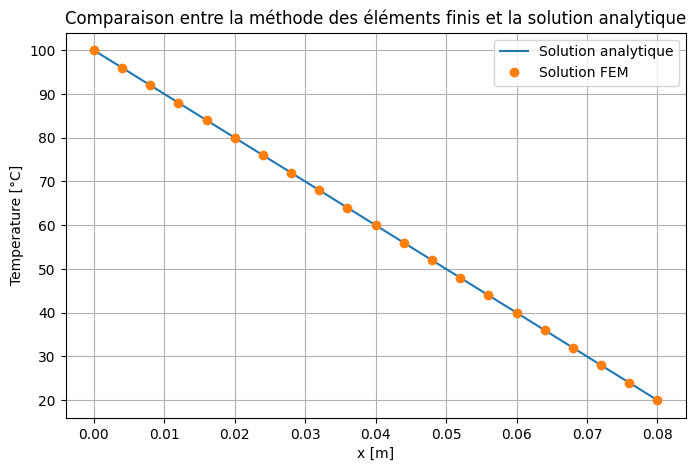

In [ ]:
plt.figure()
plt.plot(x_exact, T_exact, label="Solution analytique")
plt.plot(x_nodes, T_fem, "o", label="Solution FEM")
plt.xlabel("x [m]")
plt.ylabel("Temperature [°C]")
plt.title("Comparaison entre la méthode des éléments finis et la solution analytique")
plt.legend()
plt.show()

## 11. Extension au régime transitoire

On considère maintenant le même échantillon, toujours isolé latéralement. Le transfert thermique est donc supposé unidimensionnel, dans la direction \(x\).

L’équation étudiée devient :

$$
\frac{\partial T}{\partial t}
=
a\frac{\partial^2T}{\partial x^2}
$$

où \(a\) est la diffusivité thermique de l’échantillon :

$$
a=\frac{\lambda}{\rho c_p}
$$

Les conditions aux limites restent imposées en température :

$$
T(0,t)=T_{\mathrm{inf}}
$$

$$
T(L,t)=T_{\mathrm{sup}}
$$

La condition initiale choisie est :

$$
T(x,0)=T_{\mathrm{inf}}
$$

pour l’intérieur de l’échantillon. La température de la face supérieure est imposée à \(T_{\mathrm{sup}}\) dès \(t=0\).

La résolution temporelle est réalisée avec un schéma d’Euler explicite.

## 12. Paramètres de la simulation transitoire

Dans ce bloc, on définit les paramètres nécessaires pour résoudre l’équation de chaleur en régime transitoire :

$$
\frac{\partial T}{\partial t}
=
a\frac{\partial^2 T}{\partial x^2}
$$

où $a$ est la diffusivité thermique de l’échantillon :

$$
a=\frac{\lambda}{\rho c_p}
$$

À ce stade, la valeur de $a$ est choisie comme un paramètre de simulation. Plus tard, elle pourra être ajustée à partir des données expérimentales.

On fixe aussi le temps final de calcul, les instants auxquels on souhaite sauvegarder les profils de température, et le type de matrice de masse utilisé. Pour le schéma d’Euler explicite, la matrice de masse regroupée, ou *lumped mass matrix*, est souvent plus adaptée car elle donne une évolution temporelle plus directe et plus stable numériquement.

In [ ]:
# ============================================================
# EXTENSIÓN TRANSITORIA
# ============================================================
# Este bloque reutiliza las variables ya definidas:
# L, Tinf, Tsup, x_nodes, N_elements, N_nodes

# Difusividad térmica [m²/s]
# Este valor es provisional para simular.
# Más adelante se podrá ajustar con datos experimentales.
a = 7.0e-7

# Tipo de matriz de masa:
# "lumped"     -> matriz de masa agrupada, más adecuada para Euler explícito
# "consistent" -> matriz de masa consistente
mass_type = "lumped"

# Tiempo final de simulación [s]
t_final = 4000.0

# Tiempos que queremos graficar [s]
times_to_plot = np.array([0.0, 30.0, 100.0, 300.0, 800.0, 1500.0, 3000.0, 4000])

# Verificación básica
required_variables = ["L", "Tinf", "Tsup", "x_nodes", "N_elements", "N_nodes"]

for var in required_variables:
    if var not in globals():
        raise NameError(f"Falta la variable {var}. Ejecuta primero los bloques del caso estacionario.")

if N_elements < 2:
    raise ValueError("Para el problema transitorio se recomienda usar al menos 2 elementos.")

print("Parámetros transitorios:")
print(f"a = {a:.3e} m²/s")
print(f"mass_type = {mass_type}")
print(f"t_final = {t_final:.2f} s")

Parámetros transitorios:
a = 7.000e-07 m²/s
mass_type = lumped
t_final = 4000.00 s


## 13. Calcul de la matrice de masse élémentaire

Dans le cas transitoire, un nouveau terme apparaît à cause de la dérivée temporelle :

$$
\frac{\partial T}{\partial t}
$$

Après discrétisation par éléments finis, ce terme conduit à une matrice de masse élémentaire définie par :

$$
M^e_{lm}
=
\int_{\Omega^e}
N_l N_m \, dx
$$

Pour un élément linéaire de longueur $h^e$, avec les fonctions de forme de Lagrange :

$$
N_i(\xi)=\frac{1-\xi}{2}
$$

$$
N_j(\xi)=\frac{1+\xi}{2}
$$

la matrice de masse consistante est :

$$
M^e=
\frac{h^e}{6}
\begin{bmatrix}
2 & 1\\
1 & 2
\end{bmatrix}
$$

Cette matrice représente la contribution du stockage thermique dans chaque élément.

In [ ]:
def element_mass_p1(x_left, x_right):
    """
    Calcula la matriz de masa elemental para elementos lineales P1.

    M^e_lm = ∫ N_l N_m dx

    Para elementos lineales, el resultado teórico es:

        M^e = he/6 * [[2, 1],
                      [1, 2]]
    """

    he = x_right - x_left

    # Cuadratura de Gauss de 2 puntos
    gauss_points = np.array([
        -1.0 / np.sqrt(3.0),
         1.0 / np.sqrt(3.0)
    ])

    gauss_weights = np.array([1.0, 1.0])

    Me = np.zeros((2, 2))

    for xi, w in zip(gauss_points, gauss_weights):

        N, dN_dxi = lagrange_p1(xi)

        # Jacobiano del cambio de variable: dx = he/2 dxi
        J = he / 2.0

        Me += w * np.outer(N, N) * J

    return Me

## 14. Assemblage des matrices globales du problème transitoire

Pour le problème transitoire, deux matrices globales sont nécessaires :

$$
M
$$

la matrice de masse, associée au terme temporel, et :

$$
K
$$

la matrice de rigidité, associée au terme diffusif spatial.

Le système semi-discret obtenu après la discrétisation spatiale s’écrit :

$$
M\dot{T}+aKT=0
$$

où $\dot{T}$ représente la dérivée temporelle du vecteur des températures nodales.

L’assemblage consiste à additionner les contributions élémentaires $M^e$ et $K^e$ dans les positions correspondantes des matrices globales, selon la connectivité des nœuds.

In [ ]:
def assemble_transient_matrices(x_nodes):
    """
    Ensambla las matrices globales M y K para el problema transitorio:

        M dT/dt + a K T = 0

    donde:

        M_lm = ∫ N_l N_m dx
        K_lm = ∫ dN_l/dx dN_m/dx dx
    """

    N_nodes = len(x_nodes)

    M = np.zeros((N_nodes, N_nodes))
    K = np.zeros((N_nodes, N_nodes))

    for e in range(N_nodes - 1):

        x_left = x_nodes[e]
        x_right = x_nodes[e + 1]

        Me = element_mass_p1(x_left, x_right)

        # Reutilizamos la matriz elemental del caso estacionario
        Ke = element_stiffness_p1(x_left, x_right)

        element_nodes = [e, e + 1]

        for i_local in range(2):
            for j_local in range(2):

                i_global = element_nodes[i_local]
                j_global = element_nodes[j_local]

                M[i_global, j_global] += Me[i_local, j_local]
                K[i_global, j_global] += Ke[i_local, j_local]

    return M, K


M_consistent, K_transient = assemble_transient_matrices(x_nodes)

print("Matriz de masa consistente M:")
print(M_consistent)

print("\nMatriz de rigidez K:")
print(K_transient)

Matriz de masa consistente M:
[[0.00133333 0.00066667 0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.        ]
 [0.00066667 0.00266667 0.00066667 0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.        ]
 [0.         0.00066667 0.00266667 0.00066667 0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.        ]
 [0.         0.         0.00066667 0.00266667 0.00066667 0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.        ]
 [0.         0.         0.         0.00066667 0.00266667 0.00066667
  0.         0.         0.         0. 

## 15. Matrice de masse regroupée et séparation des nœuds

La matrice de masse consistante n’est pas diagonale. Pour un schéma d’Euler explicite, il est souvent pratique d’utiliser une matrice de masse regroupée, appelée *lumped mass matrix*. Elle est obtenue en sommant les termes de chaque ligne de la matrice de masse consistante et en plaçant cette somme sur la diagonale :

$$
M_L(i,i)=\sum_j M(i,j)
$$

Cela permet d’obtenir une matrice diagonale, plus simple à inverser numériquement.

On sépare ensuite les nœuds en deux groupes. Les nœuds de Dirichlet sont les nœuds où la température est imposée :

$$
T(0,t)=T_{\mathrm{inf}}
$$

$$
T(L,t)=T_{\mathrm{sup}}
$$

Les autres nœuds sont les nœuds libres, c’est-à-dire les inconnues du problème transitoire.

In [ ]:
def lump_mass_matrix(M):
    """
    Construye la matriz de masa agrupada.
    La masa de cada fila se concentra en la diagonal.
    """

    return np.diag(np.sum(M, axis=1))


def get_dirichlet_partition(N_nodes, Tinf, Tsup):
    """
    Separa nodos libres y nodos con condición de Dirichlet.
    """

    dirichlet_nodes = np.array([0, N_nodes - 1], dtype=int)

    dirichlet_values = np.array(
        [float(Tinf), float(Tsup)],
        dtype=float
    )

    all_nodes = np.arange(N_nodes, dtype=int)
    free_nodes = np.setdiff1d(all_nodes, dirichlet_nodes)

    return free_nodes, dirichlet_nodes, dirichlet_values


# Selección de la matriz de masa usada en la integración temporal
if mass_type.lower() == "lumped":
    M_transient = lump_mass_matrix(M_consistent)
elif mass_type.lower() == "consistent":
    M_transient = M_consistent.copy()
else:
    raise ValueError("mass_type debe ser 'lumped' o 'consistent'.")

free_nodes, dirichlet_nodes, dirichlet_values = get_dirichlet_partition(
    N_nodes,
    Tinf,
    Tsup
)

print("Nodos libres:")
print(free_nodes)

print("\nNodos Dirichlet:")
print(dirichlet_nodes)

print("\nValores Dirichlet:")
print(dirichlet_values)

print("\nMatriz de masa usada:")
print(M_transient)

Nodos libres:
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]

Nodos Dirichlet:
[ 0 20]

Valores Dirichlet:
[100.  20.]

Matriz de masa usada:
[[0.002 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.004 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.004 0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.004 0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.004 0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.004 0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.004 0.    0.    0.    0.    0.
  0.   

## 16. Estimation du pas de temps pour Euler explicite

Le schéma d’Euler explicite est conditionnellement stable. Cela signifie que le pas de temps $\Delta t$ ne peut pas être choisi arbitrairement grand.

Pour le système semi-discret :

$$
M\dot{T}+aKT=0
$$

la stabilité dépend des valeurs propres de la matrice :

$$
aM^{-1}K
$$

On note la plus grande valeur propre :

$$
\lambda_{\max}
$$

Une condition classique de stabilité est alors :

$$
\Delta t \leq \frac{2}{\lambda_{\max}}
$$

Cependant, pour éviter des oscillations numériques, on utilise souvent une condition plus conservative. Dans ce notebook, le pas de temps est calculé automatiquement avec un facteur de sécurité.

In [ ]:
def estimate_explicit_dt_non_oscillatory(M, K, x_nodes, free_nodes, a, safety):
    """
    Estima un paso de tiempo para Euler explícito.

    La condición clásica de estabilidad es:

        dt <= 2 / lambda_max

    Sin embargo, para evitar oscilaciones numéricas, usamos una condición
    más conservadora:

        dt <= 1 / lambda_max

    Esto ayuda a que la solución se acerque suavemente al régimen estacionario.
    """

    M_ff = M[np.ix_(free_nodes, free_nodes)]
    K_ff = K[np.ix_(free_nodes, free_nodes)]

    A = a * np.linalg.solve(M_ff, K_ff)

    eigvals = np.linalg.eigvals(A)
    lambda_max = np.max(np.real(eigvals))

    dt_stable = 2.0 / lambda_max
    dt_non_oscillatory = 1.0 / lambda_max

    h_min = np.min(np.diff(x_nodes))

    # Criterio práctico equivalente para malla uniforme con masa lumped:
    # r = a dt / h² <= 0.25
    dt_r025 = 0.25 * h_min**2 / a

    # Tomamos el criterio más conservador
    dt_limit = min(dt_non_oscillatory, dt_r025)

    dt = safety * dt_limit

    r = a * dt / h_min**2

    return dt, dt_stable, dt_non_oscillatory, lambda_max, r


dt, dt_stable, dt_non_oscillatory, lambda_max, r = estimate_explicit_dt_non_oscillatory(
    M_transient,
    K_transient,
    x_nodes,
    free_nodes,
    a,
    safety=0.7
)

print("Estabilidad Euler explícito:")
print(f"lambda_max = {lambda_max:.6e} 1/s")
print(f"dt límite estabilidad = {dt_stable:.6e} s")
print(f"dt límite sin oscilación = {dt_non_oscillatory:.6e} s")
print(f"dt usado = {dt:.6e} s")
print(f"r = a dt / h² = {r:.6f}")

Estabilidad Euler explícito:
lambda_max = 1.739227e-01 1/s
dt límite estabilidad = 1.149936e+01 s
dt límite sin oscilación = 5.749680e+00 s
dt usado = 4.000000e+00 s
r = a dt / h² = 0.175000


## 17. Résolution temporelle par Euler explicite

Le système transitoire réduit aux nœuds libres s’écrit :

$$
M_{ff}\dot{T}_f
+
aK_{ff}T_f
+
aK_{fd}T_d
=
0
$$

où $T_f$ contient les températures inconnues aux nœuds intérieurs, et $T_d$ contient les températures imposées aux bords :

$$
T_d=
\begin{bmatrix}
T_{\mathrm{inf}}\\
T_{\mathrm{sup}}
\end{bmatrix}
$$

On isole la dérivée temporelle :

$$
\dot{T}_f
=
-aM_{ff}^{-1}
\left(
K_{ff}T_f+K_{fd}T_d
\right)
$$

Le schéma d’Euler explicite approxime la dérivée temporelle par :

$$
\dot{T}_f^n
\approx
\frac{T_f^{n+1}-T_f^n}{\Delta t}
$$

On obtient donc la formule d’avancement temporel :

$$
T_f^{n+1}
=
T_f^n
-
\Delta t\,a\,M_{ff}^{-1}
\left(
K_{ff}T_f^n+K_{fd}T_d
\right)
$$

Après chaque pas de temps, les conditions de Dirichlet sont réimposées aux deux extrémités.

In [ ]:
def simulate_heat_transient_euler(
    M,
    K,
    x_nodes,
    a,
    Tinf,
    Tsup,
    t_final,
    dt,
    times_to_save
):
    """
    Resuelve el problema transitorio:

        ∂T/∂t = a ∂²T/∂x²

    con condiciones de Dirichlet:

        T(0,t) = Tinf
        T(L,t) = Tsup

    usando elementos finitos en espacio y Euler explícito en tiempo.
    """
    M = M.astype(float)
    K = K.astype(float)
    x_nodes = np.asarray(x_nodes, dtype=float)

    Tinf = float(Tinf)
    Tsup = float(Tsup)

    N_nodes = len(x_nodes)

    free_nodes, dirichlet_nodes, dirichlet_values = get_dirichlet_partition(
        N_nodes,
        Tinf,
        Tsup
    )

    M_ff = M[np.ix_(free_nodes, free_nodes)]
    K_ff = K[np.ix_(free_nodes, free_nodes)]
    K_fd = K[np.ix_(free_nodes, dirichlet_nodes)]

    # Número de pasos temporales
    n_steps = int(np.ceil(t_final / dt))

    # Ajustamos dt para llegar exactamente a t_final sin superar el dt calculado
    dt_eff = t_final / n_steps

    # Condición inicial:
    # interior a Tinf, con fronteras impuestas desde t=0
    T = np.full(N_nodes, float(Tinf), dtype=float)
    T[dirichlet_nodes] = dirichlet_values

    # Tiempos a guardar
    times_to_save = np.asarray(times_to_save)
    times_to_save = times_to_save[(times_to_save >= 0.0) & (times_to_save <= t_final)]
    times_to_save = np.unique(np.append(times_to_save, [0.0, t_final]))

    save_steps = set(np.round(times_to_save / dt_eff).astype(int))

    saved_profiles = []

    time_history = []
    center_temperature_history = []

    # Nodo más cercano al centro de la muestra
    center_node = np.argmin(np.abs(x_nodes - L / 2.0))

    for n in range(n_steps + 1):

        current_time = n * dt_eff

        time_history.append(current_time)
        center_temperature_history.append(T[center_node])

        if n in save_steps:
            saved_profiles.append((current_time, T.copy()))

        if n == n_steps:
            break

        # Euler explícito:
        # T_f^{n+1} = T_f^n - dt a M_ff^{-1}(K_ff T_f^n + K_fd T_d)
        rhs = K_ff @ T[free_nodes] + K_fd @ dirichlet_values

        dTdt_free = -a * np.linalg.solve(M_ff, rhs)

        T[free_nodes] = T[free_nodes] + dt_eff * dTdt_free

        # Reimponer condiciones de Dirichlet
        T[dirichlet_nodes] = dirichlet_values

    time_history = np.array(time_history)
    center_temperature_history = np.array(center_temperature_history)

    return saved_profiles, time_history, center_temperature_history, dt_eff


saved_profiles, time_history, center_temperature_history, dt_eff = simulate_heat_transient_euler(
    M_transient,
    K_transient,
    x_nodes,
    a,
    Tinf,
    Tsup,
    t_final,
    dt,
    times_to_plot
)

print(f"Simulación terminada.")
print(f"dt efectivo = {dt_eff:.6e} s")
print(f"Número de pasos = {len(time_history)-1}")

Simulación terminada.
dt efectivo = 3.996004e+00 s
Número de pasos = 1001


## Diagnostic de convergence vers le régime stationnaire

Pour vérifier que la simulation transitoire est cohérente, on compare chaque profil calculé au profil stationnaire attendu :

$$
T_{\mathrm{stat}}(x)
=
T_{\mathrm{inf}}
+
\frac{T_{\mathrm{sup}}-T_{\mathrm{inf}}}{L}x
$$

On calcule ensuite l’erreur :

$$
e(x,t)=T(x,t)-T_{\mathrm{stat}}(x)
$$

Lorsque le temps augmente, cette erreur doit diminuer. Cela signifie que la solution transitoire se rapproche progressivement du régime stationnaire.

La quantité la plus utile pour le diagnostic est l’erreur maximale absolue :

$$
\max_x |T(x,t)-T_{\mathrm{stat}}(x)|
$$

Elle doit décroître avec le temps si la simulation est stable et physiquement cohérente.

In [ ]:
# ============================================================
# Diagnóstico de convergencia hacia el régimen estacionario
# ============================================================

L_eff = x_nodes[-1] - x_nodes[0]

T_stationary = Tinf + (Tsup - Tinf) * (x_nodes - x_nodes[0]) / L_eff

diagnostic_rows = []

for time_value, T_profile in sorted(saved_profiles, key=lambda item: item[0]):

    error = T_profile - T_stationary

    diagnostic_rows.append({
        "time_s": time_value,
        "max_abs_error_C": np.max(np.abs(error)),
        "mean_abs_error_C": np.mean(np.abs(error)),
        "min_error_C": np.min(error),
        "max_error_C": np.max(error)
    })

diagnostic_df = pd.DataFrame(diagnostic_rows)

display(diagnostic_df)

,time_s,max_abs_error_C,mean_abs_error_C,min_error_C,max_error_C
0,0.000000,76.000000,36.190476,0.0,76.000000
1,31.968032,62.408828,32.709820,0.0,62.408828
2,99.900100,52.486401,28.936036,0.0,52.486401
3,299.700300,38.446130,22.430863,0.0,38.446130
4,799.200799,21.439680,12.977883,0.0,21.439680
5,1498.501499,10.080556,6.099321,0.0,10.080556
6,3000.999001,1.990766,1.204528,0.0,1.990766
7,4000.000000,0.677059,0.409659,0.0,0.677059


## 18. Visualisation des profils de température

Dans ce bloc, on trace le profil de température dans l’échantillon à différents instants.

Au début, l’intérieur de l’échantillon est supposé à la température $T_{\mathrm{inf}}$. Ensuite, la température imposée sur la face supérieure, $T_{\mathrm{sup}}$, modifie progressivement le profil thermique.

À long terme, la solution doit tendre vers le régime stationnaire :

$$
T_{\mathrm{stat}}(x)
=
T_{\mathrm{inf}}
+
\frac{T_{\mathrm{sup}}-T_{\mathrm{inf}}}{L}x
$$

La comparaison entre les profils transitoires et cette droite stationnaire permet de vérifier que la simulation évolue dans le bon sens physique.

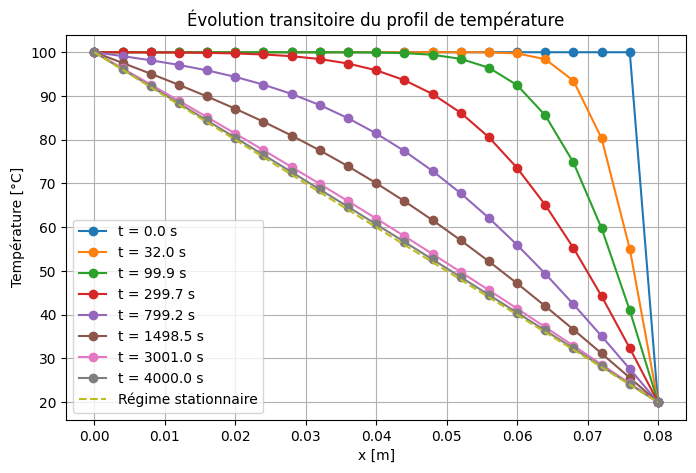

In [ ]:
# ============================================================
# Gráfica de perfiles transitorios
# ============================================================

L_eff = x_nodes[-1] - x_nodes[0]

T_stationary = Tinf + (Tsup - Tinf) * (x_nodes - x_nodes[0]) / L_eff

saved_profiles_sorted = sorted(saved_profiles, key=lambda item: item[0])

plt.figure()

for time_value, T_profile in saved_profiles_sorted:
    plt.plot(
        x_nodes,
        T_profile,
        marker="o",
        label=f"t = {time_value:.1f} s"
    )

plt.plot(
    x_nodes,
    T_stationary,
    "--",
    label="Régime stationnaire"
)

plt.xlabel("x [m]")
plt.ylabel("Température [°C]")
plt.title("Évolution transitoire du profil de température")
plt.legend()
plt.show()

## 19. Évolution temporelle de la température au centre

En plus des profils spatiaux, il est utile de suivre la température en un point particulier de l’échantillon. Ici, on observe le nœud le plus proche du centre :

$$
x=\frac{L}{2}
$$

La courbe obtenue représente l’évolution temporelle de la température au centre de l’échantillon :

$$
T\left(\frac{L}{2},t\right)
$$

Cette visualisation permet de voir comment le cœur de l’échantillon passe progressivement de la condition initiale vers la température correspondant au régime stationnaire.

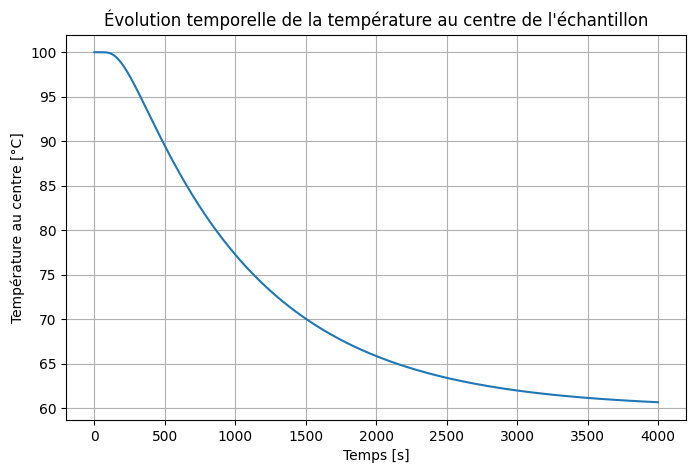

In [ ]:
plt.figure()
plt.plot(time_history, center_temperature_history)
plt.xlabel("Temps [s]")
plt.ylabel("Température au centre [°C]")
plt.title("Évolution temporelle de la température au centre de l'échantillon")
plt.show()

## 20. Résumé des paramètres de simulation

Ce bloc rassemble les principaux paramètres utilisés dans la simulation transitoire : longueur de l’échantillon, nombre d’éléments, diffusivité thermique, type de matrice de masse, pas de temps et températures imposées aux bords.

Le modèle résolu est :

$$
\frac{\partial T}{\partial t}
=
a\frac{\partial^2T}{\partial x^2}
$$

avec :

$$
T(0,t)=T_{\mathrm{inf}}
$$

$$
T(L,t)=T_{\mathrm{sup}}
$$

et :

$$
T(x,0)=T_{\mathrm{inf}}
$$

Ce résumé permet de garder une trace claire des hypothèses numériques utilisées pour produire les résultats.

In [ ]:
summary_transient_df = pd.DataFrame({
    "parameter": [
        "L_m",
        "N_elements",
        "N_nodes",
        "a_m2_s",
        "mass_type",
        "t_final_s",
        "dt_s",
        "lambda_max_1_s",
        "Tinf_C",
        "Tsup_C"
    ],
    "value": [
        L,
        N_elements,
        N_nodes,
        a,
        mass_type,
        t_final,
        dt_eff,
        lambda_max,
        Tinf,
        Tsup
    ]
})

display(summary_transient_df)

,parameter,value
0,L_m,0.08
1,N_elements,20
2,N_nodes,21
3,a_m2_s,0.000001
4,mass_type,lumped
5,t_final_s,4000.0
6,dt_s,3.996004
7,lambda_max_1_s,0.173923
8,Tinf_C,100.0
9,Tsup_C,20.0


## 21. Calcul du coefficient \(R^2\)

Pour quantifier la qualité de la simulation, on compare le profil numérique obtenu au temps final avec la solution analytique stationnaire.

La solution analytique attendue lorsque \(t\to\infty\) est :

$$
T_{\mathrm{stat}}(x)
=
T_{\mathrm{inf}}
+
\frac{T_{\mathrm{sup}}-T_{\mathrm{inf}}}{L}x
$$

Le coefficient \(R^2\) est défini par :

$$
R^2
=
1
-
\frac{
\sum_i
\left(
T_{\mathrm{num}}(x_i,t_{\mathrm{final}})
-
T_{\mathrm{stat}}(x_i)
\right)^2
}{
\sum_i
\left(
T_{\mathrm{stat}}(x_i)
-
\overline{T}_{\mathrm{stat}}
\right)^2
}
$$

Une valeur de \(R^2\) proche de 1 indique que le profil numérique au temps final est très proche de la solution analytique stationnaire.

In [ ]:
# ============================================================
# Calcul du coefficient R² au temps final
# ============================================================

def compute_r2(y_true, y_pred):
    """
    Calcule le coefficient R² entre une solution de référence y_true
    et une solution numérique y_pred.
    """

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)

    if ss_tot == 0:
        raise ValueError("Impossible de calculer R² : la solution de référence est constante.")

    r2 = 1.0 - ss_res / ss_tot

    return r2


# Trier les profils sauvegardés par temps croissant
saved_profiles_sorted = sorted(saved_profiles, key=lambda item: item[0])

# Dernier profil sauvegardé : approximation numérique de t -> infini
t_final_saved, T_final_num = saved_profiles_sorted[-1]

# Solution analytique stationnaire
L_eff = x_nodes[-1] - x_nodes[0]

T_stationary = Tinf + (Tsup - Tinf) * (x_nodes - x_nodes[0]) / L_eff

# Calcul du R²
r2_final = compute_r2(T_stationary, T_final_num)

# Erreurs complémentaires
error_final = T_final_num - T_stationary

max_abs_error = np.max(np.abs(error_final))
mean_abs_error = np.mean(np.abs(error_final))
mean_signed_error = np.mean(error_final)
rmse = np.sqrt(np.mean(error_final**2))

print("Comparaison au régime stationnaire")
print("----------------------------------")
print(f"Temps utilisé comme approximation de t -> infini : {t_final_saved:.2f} s")
print(f"R² = {r2_final:.8f}")
print(f"Erreur maximale absolue = {max_abs_error:.6e} °C")
print(f"Erreur moyenne absolue = {mean_abs_error:.6e} °C")
print(f"RMSE = {rmse:.6e} °C")
print(f"Erreur moyenne signée = {mean_signed_error:.6e} °C")

Comparaison au régime stationnaire
----------------------------------
Temps utilisé comme approximation de t -> infini : 4000.00 s
R² = 0.99962792
Erreur maximale absolue = 6.770586e-01 °C
Erreur moyenne absolue = 4.096593e-01 °C
RMSE = 4.672148e-01 °C
Erreur moyenne signée = 4.096593e-01 °C


In [ ]:
# ============================================================
# Evolution de R² avec le temps
# ============================================================

r2_rows = []

for time_value, T_profile in saved_profiles_sorted:

    error = T_profile - T_stationary

    r2_value = compute_r2(T_stationary, T_profile)

    r2_rows.append({
        "time_s": time_value,
        "R2": r2_value,
        "max_abs_error_C": np.max(np.abs(error)),
        "mean_abs_error_C": np.mean(np.abs(error)),
        "rmse_C": np.sqrt(np.mean(error**2)),
        "mean_signed_error_C": np.mean(error)
    })

r2_df = pd.DataFrame(r2_rows)

display(r2_df)




,time_s,R2,max_abs_error_C,mean_abs_error_C,rmse_C,mean_signed_error_C
0,0.000000,-2.207792,76.000000,36.190476,43.380926,36.190476
1,31.968032,-1.530497,62.408828,32.709820,38.529964,32.709820
2,99.900100,-0.944846,52.486401,28.936036,33.778344,28.936036
3,299.700300,-0.137290,38.446130,22.430863,25.830411,22.430863
4,799.200799,0.626135,21.439680,12.977883,14.809926,12.977883
5,1498.501499,0.917517,10.080556,6.099321,6.956302,6.099321
6,3000.999001,0.996783,1.990766,1.204528,1.373759,1.204528
7,4000.000000,0.999628,0.677059,0.409659,0.467215,0.409659


## 22. Test complémentaire avec un gradient thermique positif

Le cas précédent impose une température élevée à gauche et une température
faible à droite, ce qui produit un gradient thermique négatif.

Afin de vérifier que le comportement du code ne dépend pas du signe du
gradient, un deuxième cas est étudié en inversant les conditions aux limites :

$$
T(0,t)=20^\circ\mathrm{C}
$$

et

$$
T(L,t)=100^\circ\mathrm{C}
$$

Le gradient thermique stationnaire est alors positif :

$$
\frac{dT}{dx}
=
\frac{T(L)-T(0)}{L}
=
\frac{100-20}{0.08}
=
1000\ ^\circ\mathrm{C/m}
$$

La matrice de masse, la matrice de rigidité, le maillage et la diffusivité
thermique restent inchangés. Par conséquent, les limites de stabilité du
schéma d'Euler explicite sont identiques à celles du cas précédent.

Le test consiste à vérifier :

- la convergence vers la solution stationnaire linéaire ;
- l'obtention d'une pente positive ;
- le respect des températures imposées ;
- la monotonie spatiale du profil ;
- l'absence d'oscillations numériques.

In [ ]:
# ============================================================
# TEST COMPLÉMENTAIRE : GRADIENT THERMIQUE POSITIF
# ============================================================

# Conditions aux limites du nouveau cas
Tinf_positive = 20.0     # Température à x = 0 [°C]
Tsup_positive = 100.0    # Température à x = L [°C]

# ------------------------------------------------------------
# Simulation transitoire
# ------------------------------------------------------------

saved_profiles_positive, time_history_positive, \
center_temperature_positive, dt_eff_positive = (
    simulate_heat_transient_euler(
        M_transient,
        K_transient,
        x_nodes,
        a,
        Tinf_positive,
        Tsup_positive,
        t_final,
        dt,
        times_to_plot
    )
)

saved_profiles_positive = sorted(
    saved_profiles_positive,
    key=lambda item: item[0]
)

print("Simulation avec pente positive terminée.")
print(f"dt effectif = {dt_eff_positive:.6e} s")
print(f"Nombre de pas = {len(time_history_positive) - 1}")

Simulation avec pente positive terminée.
dt effectif = 3.996004e+00 s
Nombre de pas = 1001


In [ ]:
# ============================================================
# SOLUTION STATIONNAIRE ET DIAGNOSTIC
# ============================================================

L_eff = x_nodes[-1] - x_nodes[0]

# Solution analytique stationnaire
T_stationary_positive = (
    Tinf_positive
    + (Tsup_positive - Tinf_positive)
    * (x_nodes - x_nodes[0])
    / L_eff
)

# Dernier profil numérique
t_final_positive, T_final_positive = (
    saved_profiles_positive[-1]
)

# Erreur numérique
error_positive = (
    T_final_positive
    - T_stationary_positive
)

# Coefficient R²
r2_positive = compute_r2(
    T_stationary_positive,
    T_final_positive
)

# Pentes exacte et numérique
slope_exact_positive = (
    Tsup_positive - Tinf_positive
) / L_eff

slope_fem_positive = np.polyfit(
    x_nodes,
    T_final_positive,
    1
)[0]

# Erreurs complémentaires
max_error_positive = np.max(
    np.abs(error_positive)
)

rmse_positive = np.sqrt(
    np.mean(error_positive**2)
)

# ------------------------------------------------------------
# Vérification des bornes physiques
# ------------------------------------------------------------

tolerance = 1.0e-10

temperatures_bounded_positive = all(
    np.all(
        (T_profile >= Tinf_positive - tolerance)
        & (T_profile <= Tsup_positive + tolerance)
    )
    for _, T_profile in saved_profiles_positive
)

# ------------------------------------------------------------
# Vérification de la monotonie
# ------------------------------------------------------------

profiles_monotone_positive = all(
    np.all(
        np.diff(T_profile) >= -tolerance
    )
    for _, T_profile in saved_profiles_positive
)

# ------------------------------------------------------------
# Vérification du pas de temps
# ------------------------------------------------------------

stable_positive = (
    dt_eff_positive <= dt_stable
)

non_oscillatory_positive = (
    dt_eff_positive <= dt_non_oscillatory
)

# Tableau récapitulatif
positive_test_df = pd.DataFrame({
    "parametre": [
        "Pente analytique [°C/m]",
        "Pente FEM [°C/m]",
        "R² au temps final",
        "Erreur maximale [°C]",
        "RMSE [°C]",
        "Températures bornées",
        "Profils monotones",
        "Pas de temps stable",
        "Pas de temps non oscillatoire"
    ],
    "valeur": [
        slope_exact_positive,
        slope_fem_positive,
        r2_positive,
        max_error_positive,
        rmse_positive,
        temperatures_bounded_positive,
        profiles_monotone_positive,
        stable_positive,
        non_oscillatory_positive
    ]
})

display(positive_test_df)

,parametre,valeur
0,Pente analytique [°C/m],1000.0
1,Pente FEM [°C/m],999.999984
2,R² au temps final,0.999628
3,Erreur maximale [°C],0.677059
4,RMSE [°C],0.467215
5,Températures bornées,True
6,Profils monotones,True
7,Pas de temps stable,True
8,Pas de temps non oscillatoire,True


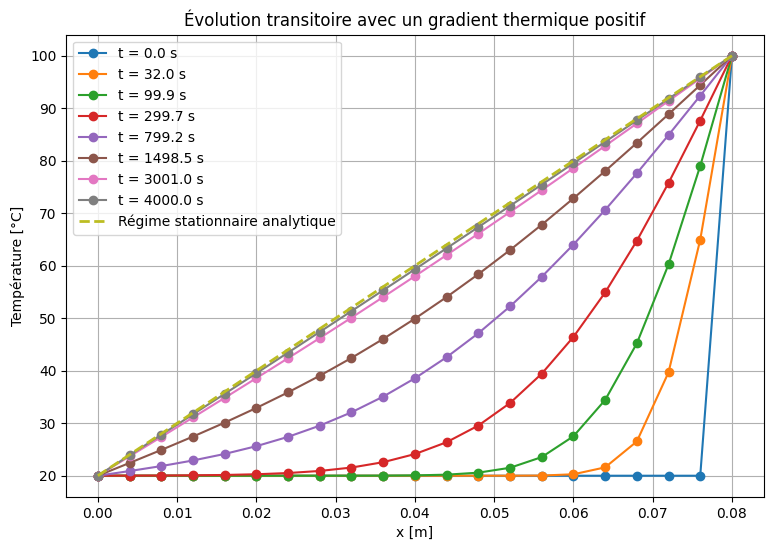

In [ ]:
# ============================================================
# PROFILS TRANSITOIRES AVEC PENTE POSITIVE
# ============================================================

plt.figure(figsize=(9, 6))

for time_value, T_profile in saved_profiles_positive:

    plt.plot(
        x_nodes,
        T_profile,
        marker="o",
        label=f"t = {time_value:.1f} s"
    )

plt.plot(
    x_nodes,
    T_stationary_positive,
    "--",
    linewidth=2,
    label="Régime stationnaire analytique"
)

plt.xlabel("x [m]")
plt.ylabel("Température [°C]")

plt.title(
    "Évolution transitoire avec un gradient thermique positif"
)

plt.legend()
plt.grid(True)
plt.show()

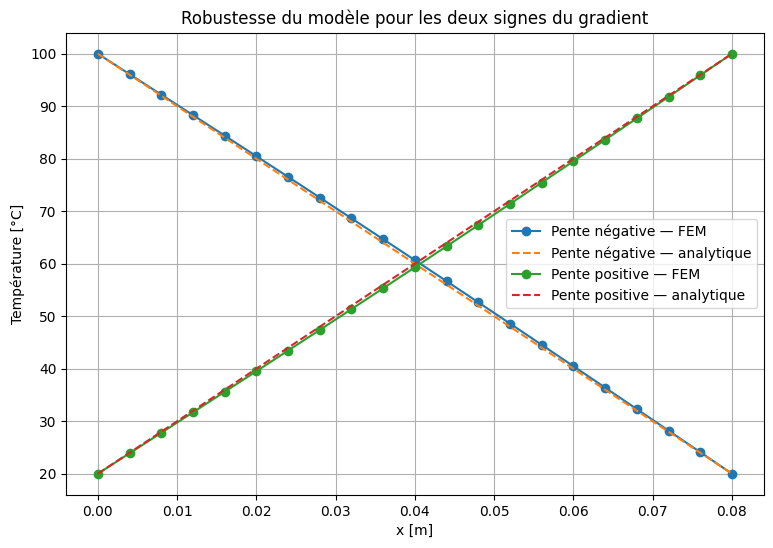

In [ ]:
# ============================================================
# COMPARAISON DES DEUX SIGNES DU GRADIENT
# ============================================================

plt.figure(figsize=(9, 6))

# Cas original : pente négative
plt.plot(
    x_nodes,
    T_final_num,
    "o-",
    label="Pente négative — FEM"
)

plt.plot(
    x_nodes,
    T_stationary,
    "--",
    label="Pente négative — analytique"
)

# Nouveau cas : pente positive
plt.plot(
    x_nodes,
    T_final_positive,
    "o-",
    label="Pente positive — FEM"
)

plt.plot(
    x_nodes,
    T_stationary_positive,
    "--",
    label="Pente positive — analytique"
)

plt.xlabel("x [m]")
plt.ylabel("Température [°C]")

plt.title(
    "Robustesse du modèle pour les deux signes du gradient"
)

plt.legend()
plt.grid(True)
plt.show()

## 22. Ajout d'une charge ponctuelle constante

On ajoute maintenant une perte thermique localisée en un point de l’échantillon. Contrairement au modèle précédent, cette perte n’est pas supposée proportionnelle à la température locale. Elle est imposée comme une charge ponctuelle constante.

Le modèle transitoire devient :

$$
\frac{\partial T}{\partial t}
=
a\frac{\partial^2 T}{\partial x^2}
-
q_p\delta(x-x_c)
$$

où $x_c$ est la position de la charge ponctuelle. Dans le cas étudié ici, on la place au centre de l’échantillon :

$$
x_c=\frac{L}{2}
$$

Le coefficient $q_p$ représente l’intensité de la perte ponctuelle. Par convention, si $q_p>0$, le terme ajouté correspond à une extraction locale de chaleur.

Après discrétisation par éléments finis, le système global s’écrit :

$$
M\dot{T}+aKT=f^p
$$

avec :

$$
f^p_l
=
-q_p N_l(x_c)
$$

Si le point $x_c$ coïncide avec un nœud de la maille, la charge agit uniquement sur ce nœud. Si ce nœud est noté $n_c$, alors :

$$
f^p_{n_c}=-q_p
$$

et toutes les autres composantes du vecteur $f^p$ sont nulles.

## 23. Définition des paramètres de la charge ponctuelle constante

Dans ce bloc, on définit les paramètres associés à la charge ponctuelle constante.

La position de la charge est notée :

$$
x_{\mathrm{load}}
$$

Dans un premier temps, on choisit de la placer au centre de l’échantillon :

$$
x_{\mathrm{load}}=\frac{L}{2}
$$

L’intensité de la charge est notée :

$$
q_{\mathrm{point}}
$$

Dans cette convention, une valeur positive de $q_{\mathrm{point}}$ représente une perte thermique. La contribution ajoutée au second membre du système est donc négative :

$$
f^p_l=-q_{\mathrm{point}}N_l(x_{\mathrm{load}})
$$

Pour l’instant, $q_{\mathrm{point}}$ est un paramètre numérique choisi pour observer l’influence d’une perte localisée. Plus tard, il pourra être ajusté à partir des données expérimentales.

In [ ]:
# ============================================================
# PARAMÈTRES DE LA CHARGE PONCTUELLE CONSTANTE
# ============================================================

# Position de la charge ponctuelle [m]
# Ici, on la place au centre de la barre.
x_load = 0.5 * (x_nodes[0] + x_nodes[-1])

# Intensité de la charge ponctuelle constante.
# Convention:
#   q_point > 0  -> perte thermique ponctuelle
#   f_point      -> contient donc -q_point au point de perte
#
# Unités cohérentes avec le modèle:
#   q_point a les unités de [°C.m/s] dans cette formulation 1D normalisée.
q_point = 4.0e-3

print("Paramètres de la charge ponctuelle constante:")
print(f"x_load  = {x_load:.6e} m")
print(f"q_point = {q_point:.6e}")

Paramètres de la charge ponctuelle constante:
x_load  = 4.000000e-02 m
q_point = 4.000000e-03


## 24. Construction du vecteur global de charge ponctuelle

On construit ici le vecteur global $f^p$ associé à la charge ponctuelle constante.

Le système global avec charge ponctuelle est :

$$
M\dot{T}+aKT=f^p
$$

La contribution de la charge ponctuelle est définie par :

$$
f^p_l
=
-q_{\mathrm{point}}N_l(x_{\mathrm{load}})
$$

Deux situations sont possibles.

Si $x_{\mathrm{load}}$ coïncide avec un nœud de la maille, la charge est appliquée uniquement sur ce nœud. Si ce nœud est noté $n_c$, alors :

$$
N_{n_c}(x_{\mathrm{load}})=1
$$

et :

$$
N_m(x_{\mathrm{load}})=0
\qquad
m\neq n_c
$$

Donc :

$$
f^p_{n_c}=-q_{\mathrm{point}}
$$

Si $x_{\mathrm{load}}$ tombe à l’intérieur d’un élément, la charge est répartie entre les deux nœuds de cet élément à l’aide des fonctions de forme de Lagrange.

In [ ]:
# ============================================================
# VECTEUR GLOBAL DE CHARGE PONCTUELLE CONSTANTE
# ============================================================

def build_constant_point_load_vector(x_nodes, x_load, q_point, tol=1e-10):
    """
    Construit le vecteur global f_point associé à une charge ponctuelle constante.

    Modèle discret:

        M dT/dt + a K T = f_point

    Convention:
        q_point > 0 correspond à une perte thermique.
        Donc la contribution ajoutée au vecteur est négative:

            f_l = -q_point N_l(x_load)

    Si x_load coïncide avec un nœud, la charge est appliquée uniquement
    à ce nœud.

    Si x_load tombe à l'intérieur d'un élément, la charge est répartie
    entre les deux nœuds de cet élément avec les fonctions de forme P1.
    """

    x_nodes = np.asarray(x_nodes, dtype=float)

    N_nodes = len(x_nodes)

    f_point = np.zeros(N_nodes, dtype=float)

    x_load = float(x_load)
    q_point = float(q_point)

    x_min = x_nodes[0]
    x_max = x_nodes[-1]

    if x_load < x_min or x_load > x_max:
        raise ValueError("x_load doit être dans le domaine.")

    L_eff = x_max - x_min

    # Vérifier si x_load coïncide avec un nœud
    distances = np.abs(x_nodes - x_load)
    nearest_node = int(np.argmin(distances))

    if distances[nearest_node] <= tol * max(1.0, L_eff):

        # Cas nodal:
        # N_nc(x_load) = 1, donc f_nc = -q_point
        f_point[nearest_node] += -q_point

        info = {
            "type": "nodal",
            "node": nearest_node,
            "x_node": x_nodes[nearest_node],
            "x_load": x_load,
            "q_point": q_point
        }

    else:

        # Cas général:
        # x_load tombe dans un élément.
        e = int(np.searchsorted(x_nodes, x_load) - 1)
        e = max(0, min(e, N_nodes - 2))

        x_left = x_nodes[e]
        x_right = x_nodes[e + 1]

        he = x_right - x_left

        # Coordonnée locale du point de charge
        xi_load = (2.0 * x_load - (x_left + x_right)) / he

        # Fonctions de forme évaluées au point de charge
        N_local, _ = lagrange_p1(xi_load)

        local_nodes = [e, e + 1]

        # Contribution locale:
        # f_l = -q_point N_l(x_load)
        f_local = -q_point * N_local

        for i_local in range(2):
            i_global = local_nodes[i_local]
            f_point[i_global] += f_local[i_local]

        info = {
            "type": "element",
            "element": e,
            "x_left": x_left,
            "x_right": x_right,
            "xi_load": xi_load,
            "N_local": N_local,
            "x_load": x_load,
            "q_point": q_point
        }

    return f_point, info


f_point, point_load_info = build_constant_point_load_vector(
    x_nodes=x_nodes,
    x_load=x_load,
    q_point=q_point
)

print("Information sur la charge ponctuelle:")
print(point_load_info)

print("\nEntrées non nulles de f_point:")
print(np.where(np.abs(f_point) > 0)[0])

print("\nValeurs non nulles de f_point:")
nonzero_indices = np.where(np.abs(f_point) > 0)[0]
for idx in nonzero_indices:
    print(f"f_point[{idx}] = {f_point[idx]:.6e}")

Information sur la charge ponctuelle:
{'type': 'nodal', 'node': 10, 'x_node': np.float64(0.04), 'x_load': 0.04, 'q_point': 0.004}

Entrées non nulles de f_point:
[10]

Valeurs non nulles de f_point:
f_point[10] = -4.000000e-03


## 25. Pas de temps pour le cas avec charge ponctuelle

L’ajout d’une charge ponctuelle constante modifie le second membre du système, mais ne modifie pas la matrice dynamique.

Le système sans charge était :

$$
M\dot{T}+aKT=0
$$

Avec la charge ponctuelle constante, il devient :

$$
M\dot{T}+aKT=f^p
$$

La stabilité du schéma d’Euler explicite dépend donc toujours de la matrice :

$$
M^{-1}aK
$$

et non du vecteur de charge $f^p$.

On peut donc réutiliser le pas de temps calculé pour le cas sans charge ponctuelle.

In [ ]:
# ============================================================
# PAS DE TEMPS POUR LE CAS AVEC CHARGE PONCTUELLE
# ============================================================

# La charge ponctuelle constante ne modifie pas la matrice dynamique.
# On peut donc réutiliser le pas de temps du cas sans perte.

try:
    dt_point_load = dt
except NameError:
    # Si la variable dt n'existe pas, on utilise le pas effectif
    # de la simulation sans perte.
    dt_point_load = dt_eff

print("Pas de temps pour le cas avec charge ponctuelle:")
print(f"dt utilisé = {dt_point_load:.6e} s")

Pas de temps pour le cas avec charge ponctuelle:
dt utilisé = 4.000000e+00 s


## 26. Résolution transitoire avec charge ponctuelle constante

On résout maintenant le problème transitoire avec charge ponctuelle constante :

$$
M\dot{T}+aKT=f^p
$$

Les températures aux deux extrémités restent imposées :

$$
T(0,t)=T_{\mathrm{inf}}
$$

$$
T(L,t)=T_{\mathrm{sup}}
$$

On sépare donc les nœuds libres et les nœuds de Dirichlet :

$$
T=
\begin{bmatrix}
T_f\\
T_d
\end{bmatrix}
$$

où $T_f$ contient les températures inconnues aux nœuds internes, et $T_d$ contient les températures imposées aux frontières.

Le système réduit aux nœuds libres est :

$$
M_{ff}\dot{T}_f
+
aK_{ff}T_f
+
aK_{fd}T_d
=
f_f^p
$$

Comme les conditions de Dirichlet sont constantes, on a :

$$
\dot{T}_d=0
$$

On obtient donc :

$$
M_{ff}\dot{T}_f
=
f_f^p
-
aK_{ff}T_f
-
aK_{fd}T_d
$$

Avec Euler explicite, la mise à jour temporelle est :

$$
T_f^{n+1}
=
T_f^n
+
\Delta t
M_{ff}^{-1}
\left(
f_f^p
-
aK_{ff}T_f^n
-
aK_{fd}T_d
\right)
$$

Cette expression est celle utilisée dans la fonction de simulation.

In [ ]:
# ============================================================
# SIMULATION TRANSITOIRE AVEC CHARGE PONCTUELLE CONSTANTE
# ============================================================

def simulate_heat_transient_euler_with_point_load(
    M,
    K,
    f_point,
    x_nodes,
    a,
    Tinf,
    Tsup,
    t_final,
    dt,
    times_to_save
):
    """
    Résout le problème transitoire avec charge ponctuelle constante:

        M dT/dt + a K T = f_point

    avec conditions de Dirichlet:

        T(0,t) = Tinf
        T(L,t) = Tsup

    en utilisant Euler explicite en temps.
    """

    M = M.astype(float)
    K = K.astype(float)
    f_point = np.asarray(f_point, dtype=float)
    x_nodes = np.asarray(x_nodes, dtype=float)

    Tinf = float(Tinf)
    Tsup = float(Tsup)

    N_nodes = len(x_nodes)

    free_nodes, dirichlet_nodes, dirichlet_values = get_dirichlet_partition(
        N_nodes,
        Tinf,
        Tsup
    )

    M_ff = M[np.ix_(free_nodes, free_nodes)]

    K_ff = K[np.ix_(free_nodes, free_nodes)]
    K_fd = K[np.ix_(free_nodes, dirichlet_nodes)]

    f_f = f_point[free_nodes]

    n_steps = int(np.ceil(t_final / dt))
    dt_eff = t_final / n_steps

    # Condition initiale:
    # intérieur à Tinf, frontières imposées dès t=0.
    T = np.full(N_nodes, Tinf, dtype=float)
    T[dirichlet_nodes] = dirichlet_values

    times_to_save = np.asarray(times_to_save, dtype=float)
    times_to_save = times_to_save[(times_to_save >= 0.0) & (times_to_save <= t_final)]
    times_to_save = np.unique(np.append(times_to_save, [0.0, t_final]))

    save_steps = set(np.round(times_to_save / dt_eff).astype(int))

    saved_profiles = []

    time_history = []
    center_temperature_history = []

    L_eff = x_nodes[-1] - x_nodes[0]
    center_node = np.argmin(np.abs(x_nodes - (x_nodes[0] + L_eff / 2.0)))

    for n in range(n_steps + 1):

        current_time = n * dt_eff

        time_history.append(current_time)
        center_temperature_history.append(T[center_node])

        if n in save_steps:
            saved_profiles.append((current_time, T.copy()))

        if n == n_steps:
            break

        diffusion_term = a * (
            K_ff @ T[free_nodes]
            +
            K_fd @ dirichlet_values
        )

        # Système réduit:
        # M_ff dT_f/dt = f_f - a(K_ff T_f + K_fd T_d)
        rhs = f_f - diffusion_term

        dTdt_free = np.linalg.solve(M_ff, rhs)

        T[free_nodes] = T[free_nodes] + dt_eff * dTdt_free

        # Réimposer les conditions de Dirichlet
        T[dirichlet_nodes] = dirichlet_values

    time_history = np.array(time_history, dtype=float)
    center_temperature_history = np.array(center_temperature_history, dtype=float)

    return saved_profiles, time_history, center_temperature_history, dt_eff

## 27. Exécution de la simulation avec charge ponctuelle constante

Dans ce bloc, on lance la simulation transitoire avec la charge ponctuelle constante.

On utilise les matrices globales déjà construites :

$$
M
$$

et :

$$
K
$$

ainsi que le vecteur global de charge ponctuelle :

$$
f^p
$$

La condition initiale reste identique au cas sans charge : l’intérieur de l’échantillon est initialement à la température $T_{\mathrm{inf}}$, tandis que les températures aux deux frontières sont imposées dès le début du calcul.

Les profils de température sont sauvegardés à différents instants afin de comparer ensuite l’évolution avec et sans charge ponctuelle.

In [ ]:
# ============================================================
# EXÉCUTION DU CAS AVEC CHARGE PONCTUELLE CONSTANTE
# ============================================================

saved_profiles_point_load, time_history_point_load, center_temperature_history_point_load, dt_eff_point_load = simulate_heat_transient_euler_with_point_load(
    M=M_transient,
    K=K_transient,
    f_point=f_point,
    x_nodes=x_nodes,
    a=a,
    Tinf=Tinf,
    Tsup=Tsup,
    t_final=t_final,
    dt=dt_point_load,
    times_to_save=times_to_plot
)

print("Simulation avec charge ponctuelle constante terminée.")
print(f"dt effectif = {dt_eff_point_load:.6e} s")
print(f"nombre de pas = {len(time_history_point_load)-1}")
print(f"dtype du dernier profil = {saved_profiles_point_load[-1][1].dtype}")

Simulation avec charge ponctuelle constante terminée.
dt effectif = 3.996004e+00 s
nombre de pas = 1001
dtype du dernier profil = float64


## 28. Visualisation des profils avec charge ponctuelle constante

On trace ici les profils de température obtenus avec la charge ponctuelle constante.

La position de la charge est indiquée sur la figure :

$$
x=x_{\mathrm{load}}
$$

Le profil stationnaire sans charge est également tracé comme référence :

$$
T_{\mathrm{stat}}(x)
=
T_{\mathrm{inf}}
+
\frac{T_{\mathrm{sup}}-T_{\mathrm{inf}}}{L}x
$$

Cette droite correspond au régime permanent du problème sans charge ponctuelle.

Avec une charge ponctuelle constante, le profil final peut s’écarter de cette droite. La charge localisée modifie le bilan thermique au point où elle est appliquée.

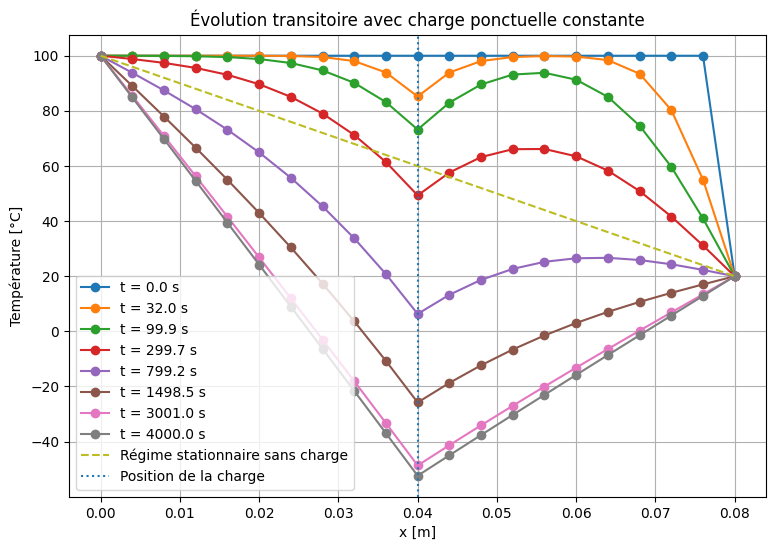

In [ ]:
# ============================================================
# PROFILS DE TEMPÉRATURE AVEC CHARGE PONCTUELLE CONSTANTE
# ============================================================

saved_profiles_point_load_sorted = sorted(
    saved_profiles_point_load,
    key=lambda item: item[0]
)

L_eff = x_nodes[-1] - x_nodes[0]

T_stationary_no_load = Tinf + (Tsup - Tinf) * (x_nodes - x_nodes[0]) / L_eff

plt.figure(figsize=(9, 6))

for time_value, T_profile in saved_profiles_point_load_sorted:
    plt.plot(
        x_nodes,
        T_profile,
        marker="o",
        label=f"t = {time_value:.1f} s"
    )

plt.plot(
    x_nodes,
    T_stationary_no_load,
    "--",
    label="Régime stationnaire sans charge"
)

plt.axvline(
    x_load,
    linestyle=":",
    label="Position de la charge"
)

plt.xlabel("x [m]")
plt.ylabel("Température [°C]")
plt.title("Évolution transitoire avec charge ponctuelle constante")
plt.legend()
plt.show()

## 29. Comparaison au temps final : sans charge et avec charge ponctuelle

On compare ici le profil final obtenu sans charge ponctuelle avec le profil final obtenu avec une charge ponctuelle constante.

Le cas sans charge vérifie :

$$
M\dot{T}+aKT=0
$$

Le cas avec charge ponctuelle vérifie :

$$
M\dot{T}+aKT=f^p
$$

La comparaison permet d’observer directement l’influence de la charge localisée sur la distribution de température dans l’échantillon.

On s’attend à ce que l’effet principal apparaisse autour de la position :

$$
x_{\mathrm{load}}=\frac{L}{2}
$$

Si la charge représente une perte thermique, le profil avec charge peut être plus faible localement que le profil sans charge.

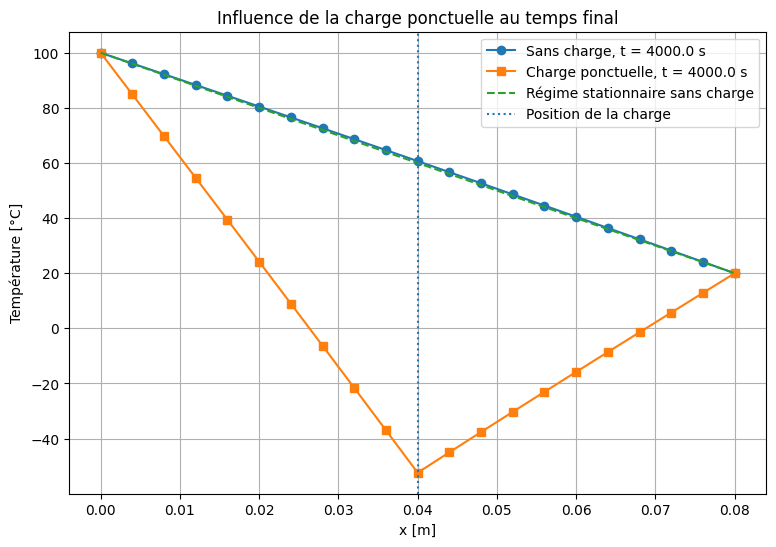

In [ ]:
# ============================================================
# COMPARAISON AU TEMPS FINAL : SANS CHARGE VS CHARGE PONCTUELLE
# ============================================================

def get_last_profile(saved_profiles):
    """
    Retourne le dernier profil sauvegardé.
    """

    saved_profiles_sorted = sorted(saved_profiles, key=lambda item: item[0])
    return saved_profiles_sorted[-1]


t_final_no_load, T_final_no_load = get_last_profile(saved_profiles)
t_final_point_load, T_final_point_load = get_last_profile(saved_profiles_point_load)

plt.figure(figsize=(9, 6))

plt.plot(
    x_nodes,
    T_final_no_load,
    marker="o",
    label=f"Sans charge, t = {t_final_no_load:.1f} s"
)

plt.plot(
    x_nodes,
    T_final_point_load,
    marker="s",
    label=f"Charge ponctuelle, t = {t_final_point_load:.1f} s"
)

plt.plot(
    x_nodes,
    T_stationary_no_load,
    "--",
    label="Régime stationnaire sans charge"
)

plt.axvline(
    x_load,
    linestyle=":",
    label="Position de la charge"
)

plt.xlabel("x [m]")
plt.ylabel("Température [°C]")
plt.title("Influence de la charge ponctuelle au temps final")
plt.legend()
plt.show()

## 30. Évolution de la température au centre de l’échantillon

On compare maintenant l’évolution temporelle de la température au centre de l’échantillon pour les deux cas :

$$
\text{sans charge}
$$

et :

$$
\text{avec charge ponctuelle}
$$

Le point observé est proche de :

$$
x=\frac{L}{2}
$$

Cette comparaison est utile car la charge ponctuelle est placée au centre de la barre dans cette première configuration.

Si la charge ponctuelle agit comme une perte thermique, la température au centre doit être plus faible que dans le cas sans charge, surtout lorsque l’effet de la charge devient significatif au cours du temps.

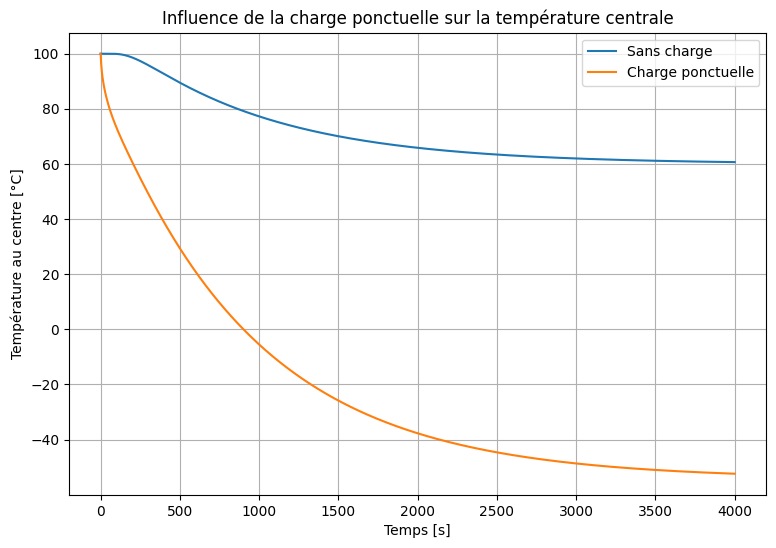

In [ ]:
# ============================================================
# TEMPÉRATURE AU CENTRE : SANS CHARGE VS CHARGE PONCTUELLE
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    time_history,
    center_temperature_history,
    label="Sans charge"
)

plt.plot(
    time_history_point_load,
    center_temperature_history_point_load,
    label="Charge ponctuelle"
)

plt.xlabel("Temps [s]")
plt.ylabel("Température au centre [°C]")
plt.title("Influence de la charge ponctuelle sur la température centrale")
plt.legend()
plt.show()

## 31. Diagnostic de l’effet de la charge ponctuelle

Dans ce bloc, on calcule la différence entre le profil final avec charge ponctuelle et le profil final sans charge :

$$
\Delta T(x)
=
T_{\mathrm{charge}}(x,t_f)
-
T_{\mathrm{sans\ charge}}(x,t_f)
$$

Cette différence permet de quantifier l’effet de la charge ponctuelle sur chaque nœud de la maille.

Si :

$$
\Delta T(x)<0
$$

alors le cas avec charge ponctuelle est plus froid que le cas sans charge à la position $x$.

Le tableau permet d’identifier les zones les plus affectées par la charge, tandis que les valeurs minimale, maximale et moyenne de $\Delta T$ donnent une synthèse globale de son influence.

In [ ]:
# ============================================================
# DIAGNOSTIC NUMÉRIQUE DU CAS AVEC CHARGE PONCTUELLE
# ============================================================

difference_final = T_final_point_load - T_final_no_load

diagnostic_point_load_df = pd.DataFrame({
    "x_m": x_nodes,
    "T_sans_charge_C": T_final_no_load,
    "T_charge_ponctuelle_C": T_final_point_load,
    "difference_C": difference_final
})

display(diagnostic_point_load_df)

print("Résumé de l'effet de la charge ponctuelle au temps final:")
print(f"Différence minimale = {np.min(difference_final):.6e} °C")
print(f"Différence maximale = {np.max(difference_final):.6e} °C")
print(f"Différence moyenne = {np.mean(difference_final):.6e} °C")

,x_m,T_sans_charge_C,T_charge_ponctuelle_C,difference_C
0,0.000,100.000000,100.000000,0.000000
1,0.004,96.105915,84.870789,-11.235126
2,0.008,92.209222,69.734207,-22.475016
3,0.012,88.307378,54.583063,-33.724314
4,0.016,84.397964,39.410528,-44.987436
5,0.020,80.478752,24.210296,-56.268456
6,0.024,76.547751,8.976745,-67.571006
7,0.028,72.603263,-6.294927,-78.898190
8,0.032,68.643920,-21.608584,-90.252504
9,0.036,64.668723,-36.967055,-101.635777


Résumé de l'effet de la charge ponctuelle au temps final:
Différence minimale = -1.130491e+02 °C
Différence maximale = 0.000000e+00 °C
Différence moyenne = -5.367356e+01 °C


## Paramètres du cas ponctuel stationnaire

On étudie maintenant le régime stationnaire avec une charge ponctuelle constante appliquée en un point de l’échantillon.

Le problème considéré est :

$$
0=\alpha \frac{d^2T}{dx^2}-s_{\mathrm{point}}\delta(x-x_c)
$$

ou, de manière équivalente :

$$
\alpha \frac{d^2T}{dx^2}
=
s_{\mathrm{point}}\delta(x-x_c)
$$

où $x_c$ est la position de la charge ponctuelle, et $s_{\mathrm{point}}$ son intensité.

Les conditions aux limites restent imposées aux extrémités :

$$
T(0)=T_{\mathrm{inf}}
$$

$$
T(L)=T_{\mathrm{sup}}
$$

Dans le code, on réutilise la position de la charge ponctuelle déjà définie :

$$
x_c=x_{\mathrm{load}}
$$

et son intensité :

$$
s_{\mathrm{point}}=q_{\mathrm{point}}
$$

Le rapport important est :

$$
\frac{s_{\mathrm{point}}}{\alpha}
$$

car il contrôle le saut de pente induit par la charge ponctuelle.

In [ ]:
# ============================================================
# PARAMÈTRES DU CAS PONCTUEL STATIONNAIRE
# ============================================================

L_eff = x_nodes[-1] - x_nodes[0]
alpha_fem = float(a)

# On réutilise la position et l'intensité déjà définies
# pour la charge ponctuelle constante.
#
# x_load  : position physique de la charge ponctuelle
# q_point : intensité de la charge ponctuelle constante
#
# Convention :
#
#   0 = alpha T'' - q_point delta(x - x_load)
#
# donc :
#
#   alpha T'' = q_point delta(x - x_load)

x_c = float(x_load)
s_point = float(q_point)

print("Paramètres du cas ponctuel stationnaire :")
print(f"L_eff     = {L_eff:.6e} m")
print(f"alpha_fem = {alpha_fem:.6e}")
print(f"x_c       = {x_c:.6e} m")
print(f"s_point   = {s_point:.6e}")
print(f"s_point / alpha_fem = {s_point / alpha_fem:.6e}")

Paramètres du cas ponctuel stationnaire :
L_eff     = 8.000000e-02 m
alpha_fem = 7.000000e-07
x_c       = 4.000000e-02 m
s_point   = 4.000000e-03
s_point / alpha_fem = 5.714286e+03


## Solution analytique avec la fonction de Heaviside

Pour obtenir la solution analytique, on utilise la relation entre la delta de Dirac et la fonction de Heaviside :

$$
\frac{d}{dx}H(x-x_c)=\delta(x-x_c)
$$

À partir de l’équation :

$$
\alpha \frac{d^2T}{dx^2}
=
s_{\mathrm{point}}\delta(x-x_c)
$$

on écrit :

$$
\alpha \frac{d^2T}{dx^2}
=
s_{\mathrm{point}}
\frac{d}{dx}H(x-x_c)
$$

En intégrant une première fois par rapport à $x$, on obtient :

$$
\alpha \frac{dT}{dx}
=
s_{\mathrm{point}}H(x-x_c)+A
$$

où $A$ est une constante d’intégration.

Ainsi, la pente de la température dépend de la position par rapport au point $x_c$.

Pour :

$$
x<x_c
$$

on a :

$$
H(x-x_c)=0
$$

donc :

$$
\frac{dT_1}{dx}
=
\frac{A}{\alpha}
$$

La solution est donc linéaire :

$$
T_1(x)=m_1x+B_1
$$

Pour :

$$
x>x_c
$$

on a :

$$
H(x-x_c)=1
$$

donc :

$$
\frac{dT_2}{dx}
=
\frac{A+s_{\mathrm{point}}}{\alpha}
$$

La solution est également linéaire, mais avec une pente différente :

$$
T_2(x)=m_2x+B_2
$$

La charge ponctuelle ne crée donc pas une courbure répartie dans une zone. Elle crée un changement brutal de pente en $x=x_c$.

## Expression explicite de la solution analytique

La solution est constituée de deux parties linéaires :

$$
T(x)
=
\begin{cases}
T_1(x), & 0\leq x\leq x_c\\
T_2(x), & x_c\leq x\leq L
\end{cases}
$$

La température reste continue au point de charge :

$$
T_1(x_c)=T_2(x_c)
$$

mais sa dérivée présente un saut :

$$
T_2'(x_c)-T_1'(x_c)
=
\frac{s_{\mathrm{point}}}{\alpha}
$$

ou encore :

$$
\alpha
\left[
T_2'(x_c)-T_1'(x_c)
\right]
=
s_{\mathrm{point}}
$$

Les pentes des deux segments sont :

$$
m_{\mathrm{left}}
=
\frac{T_{\mathrm{sup}}-T_{\mathrm{inf}}}{L}
-
\frac{s_{\mathrm{point}}}{\alpha}
\frac{L-x_c}{L}
$$

et :

$$
m_{\mathrm{right}}
=
\frac{T_{\mathrm{sup}}-T_{\mathrm{inf}}}{L}
+
\frac{s_{\mathrm{point}}}{\alpha}
\frac{x_c}{L}
$$

La solution peut alors s’écrire sous la forme compacte :

$$
T(x)
=
T_{\mathrm{inf}}
+
m_{\mathrm{left}}x
+
\frac{s_{\mathrm{point}}}{\alpha}
(x-x_c)H(x-x_c)
$$

Dans le code, le terme :

$$
(x-x_c)H(x-x_c)
$$

est évalué numériquement par :

$$
\max(x-x_c,0)
$$

ce qui permet d’écrire la solution analytique sans définir explicitement la fonction de Heaviside.

In [ ]:
# ============================================================
# SOLUTION ANALYTIQUE STATIONNAIRE AVEC CHARGE PONCTUELLE
# ============================================================

def analytical_point_load_solution(x, L, Tinf, Tsup, alpha, s_point, x_c):
    """
    Solution analytique du problème stationnaire :

        0 = alpha d²T/dx² - s_point delta(x - x_c)

    avec :

        T(0) = Tinf
        T(L) = Tsup

    La solution est composée de deux droites, avec un changement
    de pente en x = x_c.
    """

    x = np.asarray(x, dtype=float)

    L = float(L)
    Tinf = float(Tinf)
    Tsup = float(Tsup)
    alpha = float(alpha)
    s_point = float(s_point)
    x_c = float(x_c)

    if not (0.0 <= x_c <= L):
        raise ValueError("x_c doit être dans le domaine [0, L].")

    # Pente à gauche de la charge ponctuelle
    m_left = (
        (Tsup - Tinf) / L
        -
        (s_point / alpha) * (L - x_c) / L
    )

    # Pente à droite de la charge ponctuelle
    m_right = (
        (Tsup - Tinf) / L
        +
        (s_point / alpha) * x_c / L
    )

    # Forme compacte avec Heaviside :
    #
    # T(x) = Tinf + m_left x + (s_point/alpha) (x - x_c) H(x - x_c)
    #
    # Numériquement, (x - x_c)H(x - x_c) = max(x - x_c, 0)
    T = (
        Tinf
        +
        m_left * x
        +
        (s_point / alpha) * np.maximum(x - x_c, 0.0)
    )

    constants = {
        "m_left": m_left,
        "m_right": m_right,
        "s_over_alpha": s_point / alpha,
        "jump_slope": m_right - m_left #Diferencia entre las pendientes
    }

    return T, constants


# Coordonnées locales pour la solution analytique : x in [0, L]
x_nodes_local = x_nodes - x_nodes[0]
x_c_local = x_c - x_nodes[0]

T_analytic_point_nodes, constants_point = analytical_point_load_solution(
    x=x_nodes_local,
    L=L_eff,
    Tinf=Tinf,
    Tsup=Tsup,
    alpha=alpha_fem,
    s_point=s_point,
    x_c=x_c_local
)

print("Constantes de la solution analytique ponctuelle :")
for key, value in constants_point.items():
    print(f"{key} = {value:.6e}")

print("\nVérification du saut de pente :")
print(f"m_right - m_left = {constants_point['jump_slope']:.6e}")
print(f"s_point / alpha  = {constants_point['s_over_alpha']:.6e}")

Constantes de la solution analytique ponctuelle :
m_left = -3.857143e+03
m_right = 1.857143e+03
s_over_alpha = 5.714286e+03
jump_slope = 5.714286e+03

Vérification du saut de pente :
m_right - m_left = 5.714286e+03
s_point / alpha  = 5.714286e+03


## Construction du vecteur de charge ponctuelle

La delta de Dirac n’est pas ajoutée comme une équation supplémentaire. Elle apparaît dans la formulation faible sous la forme d’un terme de charge.

On part de :

$$
0=\alpha \frac{d^2T}{dx^2}
-
s_{\mathrm{point}}\delta(x-x_c)
$$

En multipliant par une fonction test $W_l$ et en intégrant sur le domaine, on obtient :

$$
\int_0^L
W_l
\left(
\alpha \frac{d^2T}{dx^2}
-
s_{\mathrm{point}}\delta(x-x_c)
\right)
dx
=
0
$$

Après intégration par parties du terme diffusif et en utilisant les conditions de Dirichlet, la forme faible devient :

$$
\alpha
\int_0^L
\frac{dW_l}{dx}
\frac{dT}{dx}
dx
=
-
s_{\mathrm{point}}W_l(x_c)
$$

Avec la méthode de Galerkin :

$$
W_l=N_l
$$

et l’approximation :

$$
T(x)=\sum_m T_mN_m(x)
$$

on obtient :

$$
\alpha
\sum_m T_m
\int_0^L
\frac{dN_l}{dx}
\frac{dN_m}{dx}
dx
=
-
s_{\mathrm{point}}N_l(x_c)
$$

Le système discret est donc :

$$
\alpha KT=F
$$

avec :

$$
F_l=-s_{\mathrm{point}}N_l(x_c)
$$

C’est dans ce vecteur $F$ que la contribution de la delta de Dirac est incorporée.

## Résolution FEM stationnaire avec charge ponctuelle

Le système éléments finis à résoudre est :

$$
\alpha KT=F
$$

où la matrice $K$ est la matrice de rigidité déjà construite pour le problème stationnaire, et où le vecteur $F$ contient la contribution de la charge ponctuelle :

$$
F_l=-s_{\mathrm{point}}N_l(x_c)
$$

Si le point $x_c$ coïncide avec un nœud de la maille, noté $n_c$, alors la propriété nodale des fonctions de Lagrange donne :

$$
N_{n_c}(x_c)=1
$$

et :

$$
N_l(x_c)=0
\qquad
l\neq n_c
$$

Dans ce cas, le vecteur de charge est nul partout sauf au nœud $n_c$ :

$$
F_{n_c}=-s_{\mathrm{point}}
$$

La résolution utilise ensuite les mêmes conditions de Dirichlet que dans le cas sans perte :

$$
T(0)=T_{\mathrm{inf}}
$$

$$
T(L)=T_{\mathrm{sup}}
$$

La fonction de résolution impose ces conditions fortement, puis résout uniquement les températures aux nœuds libres.

In [ ]:
# ============================================================
# SOLUTION FEM STATIONNAIRE AVEC CHARGE PONCTUELLE
# ============================================================

# On réutilise la matrice de rigidité globale déjà construite.
if "K_global" in globals() and K_global.shape == (len(x_nodes), len(x_nodes)):
    K_point = K_global.copy()
else:
    K_point, _ = assemble_global_system(x_nodes)

# On reconstruit le vecteur ponctuel avec la fonction déjà définie.
# Convention :
#
#   F_l = -s_point N_l(x_c)
#
# ce qui correspond à :
#
#   alpha K T = F

F_point_stationary, point_stationary_info = build_constant_point_load_vector(
    x_nodes=x_nodes,
    x_load=x_c,
    q_point=s_point
)

print("Information sur la charge ponctuelle stationnaire :")
print(point_stationary_info)

print("\nEntrées non nulles de F_point_stationary :")
nonzero_F_point = np.where(np.abs(F_point_stationary) > 1e-15)[0]
print(nonzero_F_point)

print("\nValeurs non nulles de F_point_stationary :")
for idx in nonzero_F_point:
    print(f"F_point_stationary[{idx}] = {F_point_stationary[idx]:.6e}")

print("\nSomme du vecteur F_point_stationary :")
print(f"Somme numérique = {np.sum(F_point_stationary):.6e}")
print(f"Valeur attendue = {-s_point:.6e}")


T_fem_point_stationary, K_reduced_point, F_reduced_point, free_nodes_point = solve_dirichlet_strong(
    alpha_fem * K_point,
    F_point_stationary,
    Tinf,
    Tsup
)

print("\nRésolution FEM stationnaire avec charge ponctuelle terminée.")
print(f"T_min FEM = {np.min(T_fem_point_stationary):.6f} °C")
print(f"T_max FEM = {np.max(T_fem_point_stationary):.6f} °C")

Information sur la charge ponctuelle stationnaire :
{'type': 'nodal', 'node': 10, 'x_node': np.float64(0.04), 'x_load': 0.04, 'q_point': 0.004}

Entrées non nulles de F_point_stationary :
[10]

Valeurs non nulles de F_point_stationary :
F_point_stationary[10] = -4.000000e-03

Somme du vecteur F_point_stationary :
Somme numérique = -4.000000e-03
Valeur attendue = -4.000000e-03

Résolution FEM stationnaire avec charge ponctuelle terminée.
T_min FEM = -54.285714 °C
T_max FEM = 100.000000 °C


## Comparaison entre la solution FEM et la solution analytique

On compare maintenant la solution obtenue par éléments finis avec la solution analytique.

La solution analytique est composée de deux segments linéaires :

$$
T(x)
=
\begin{cases}
T_{\mathrm{inf}}+m_{\mathrm{left}}x,
& 0\leq x\leq x_c\\[6pt]
T_{\mathrm{inf}}+m_{\mathrm{left}}x
+
\dfrac{s_{\mathrm{point}}}{\alpha}(x-x_c),
& x_c\leq x\leq L
\end{cases}
$$

La solution FEM est obtenue en résolvant :

$$
\alpha KT=F
$$

avec :

$$
F_l=-s_{\mathrm{point}}N_l(x_c)
$$

La droite sans charge ponctuelle est également tracée comme référence :

$$
T_{\mathrm{sans\ charge}}(x)
=
T_{\mathrm{inf}}
+
\frac{T_{\mathrm{sup}}-T_{\mathrm{inf}}}{L}x
$$

La position de la charge ponctuelle est indiquée sur la figure par une ligne verticale en :

$$
x=x_c
$$

Si le modèle est correctement implémenté, la solution FEM doit suivre la solution analytique et présenter un changement de pente au point $x_c$.

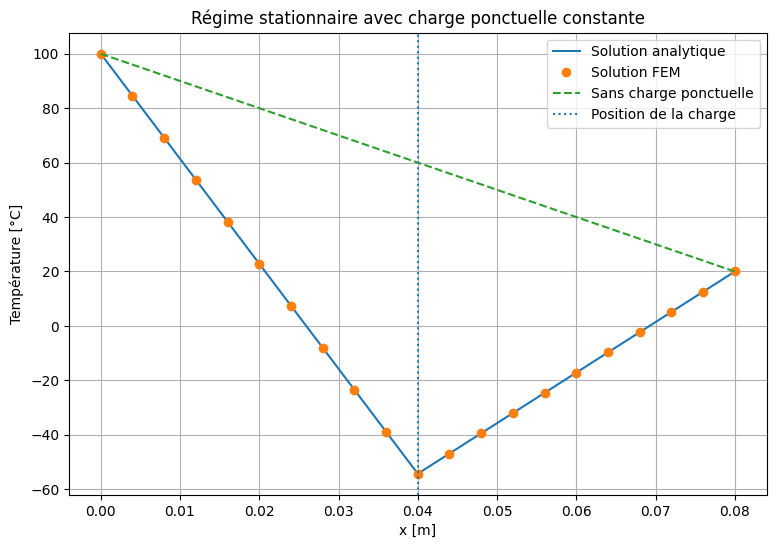

In [ ]:
# ============================================================
# COMPARAISON FEM / ANALYTIQUE : CHARGE PONCTUELLE
# ============================================================

x_fine = np.linspace(x_nodes[0], x_nodes[-1], 500)
x_fine_local = x_fine - x_nodes[0]

T_analytic_point_fine, _ = analytical_point_load_solution(
    x=x_fine_local,
    L=L_eff,
    Tinf=Tinf,
    Tsup=Tsup,
    alpha=alpha_fem,
    s_point=s_point,
    x_c=x_c_local
)

T_no_point = Tinf + (Tsup - Tinf) * (x_nodes - x_nodes[0]) / L_eff

plt.figure(figsize=(9, 6))

plt.plot(
    x_fine,
    T_analytic_point_fine,
    label="Solution analytique"
)

plt.plot(
    x_nodes,
    T_fem_point_stationary,
    marker="o",
    linestyle="",
    label="Solution FEM"
)

plt.plot(
    x_nodes,
    T_no_point,
    "--",
    label="Sans charge ponctuelle"
)

plt.axvline(
    x_c,
    linestyle=":",
    label="Position de la charge"
)

plt.xlabel("x [m]")
plt.ylabel("Température [°C]")
plt.title("Régime stationnaire avec charge ponctuelle constante")
plt.grid(True)
plt.legend()
plt.show()

## Diagnostic numérique de la solution ponctuelle

On quantifie l’écart entre la solution FEM et la solution analytique aux nœuds de la maille :

$$
e_i
=
T_{\mathrm{FEM}}(x_i)
-
T_{\mathrm{analytique}}(x_i)
$$

On calcule ensuite l’erreur absolue maximale :

$$
e_{\max}
=
\max_i |e_i|
$$

la racine de l’erreur quadratique moyenne :

$$
\mathrm{RMSE}
=
\sqrt{
\frac{1}{N}
\sum_{i=1}^{N}e_i^2
}
$$

et le coefficient de détermination :

$$
R^2
=
1
-
\frac{
\sum_i
\left(
T_{\mathrm{FEM}}(x_i)
-
T_{\mathrm{analytique}}(x_i)
\right)^2
}{
\sum_i
\left(
T_{\mathrm{analytique}}(x_i)
-
\overline{T}_{\mathrm{analytique}}
\right)^2
}
$$

Une valeur de $R^2$ proche de 1 indique que la solution FEM reproduit correctement la solution analytique.

On vérifie aussi le saut de pente analytique :

$$
m_{\mathrm{right}}-m_{\mathrm{left}}
=
\frac{s_{\mathrm{point}}}{\alpha}
$$

Cette relation est la signature de la contribution ponctuelle représentée par la delta de Dirac.

In [ ]:
# ============================================================
# DIAGNOSTIC NUMÉRIQUE : FEM VS ANALYTIQUE
# ============================================================

error_point = T_fem_point_stationary - T_analytic_point_nodes

ss_res_point = np.sum(error_point**2)
ss_tot_point = np.sum(
    (T_analytic_point_nodes - np.mean(T_analytic_point_nodes))**2
)

R2_point = 1.0 - ss_res_point / ss_tot_point

diagnostic_point_df = pd.DataFrame({
    "node": np.arange(len(x_nodes)),
    "x_m": x_nodes,
    "T_FEM_C": T_fem_point_stationary,
    "T_analytique_C": T_analytic_point_nodes,
    "erreur_C": error_point,
    "abs_erreur_C": np.abs(error_point)
})

display(diagnostic_point_df)

print("Diagnostic FEM vs analytique pour la charge ponctuelle :")
print(f"R²                  = {R2_point:.10f}")
print(f"Erreur max abs [°C] = {np.max(np.abs(error_point)):.6e}")
print(f"Erreur moyenne [°C] = {np.mean(error_point):.6e}")
print(f"RMSE [°C]           = {np.sqrt(np.mean(error_point**2)):.6e}")

print("\nVérification du saut de pente analytique :")
print(f"m_left  = {constants_point['m_left']:.6e}")
print(f"m_right = {constants_point['m_right']:.6e}")
print(f"m_right - m_left = {constants_point['jump_slope']:.6e}")
print(f"s_point / alpha  = {constants_point['s_over_alpha']:.6e}")

,node,x_m,T_FEM_C,T_analytique_C,erreur_C,abs_erreur_C
0,0,0.000,100.000000,100.000000,0.000000e+00,0.000000e+00
1,1,0.004,84.571429,84.571429,0.000000e+00,0.000000e+00
2,2,0.008,69.142857,69.142857,0.000000e+00,0.000000e+00
3,3,0.012,53.714286,53.714286,-7.105427e-15,7.105427e-15
4,4,0.016,38.285714,38.285714,-1.421085e-14,1.421085e-14
5,5,0.020,22.857143,22.857143,3.552714e-15,3.552714e-15
6,6,0.024,7.428571,7.428571,6.217249e-15,6.217249e-15
7,7,0.028,-8.000000,-8.000000,1.065814e-14,1.065814e-14
8,8,0.032,-23.428571,-23.428571,0.000000e+00,0.000000e+00
9,9,0.036,-38.857143,-38.857143,7.105427e-15,7.105427e-15


Diagnostic FEM vs analytique pour la charge ponctuelle :
R²                  = 1.0000000000
Erreur max abs [°C] = 2.842171e-14
Erreur moyenne [°C] = 5.202188e-15
RMSE [°C]           = 1.288988e-14

Vérification du saut de pente analytique :
m_left  = -3.857143e+03
m_right = 1.857143e+03
m_right - m_left = 5.714286e+03
s_point / alpha  = 5.714286e+03


## Définition des paramètres de la fuite distribuée

On considère maintenant une fuite thermique distribuée sur une portion de l’échantillon. Contrairement au cas ponctuel, la fuite n’est pas appliquée en un seul point, mais sur un intervalle :

$$
x\in[x_a,x_b]
$$

Le problème stationnaire étudié est :

$$
0=\alpha \frac{d^2T}{dx^2}-q_{\mathrm{dist}}\chi_{[x_a,x_b]}(x)
$$

où la fonction indicatrice vaut :

$$
\chi_{[x_a,x_b]}(x)
=
\begin{cases}
1, & x_a\leq x\leq x_b\\
0, & \text{ailleurs}
\end{cases}
$$

La constante $q_{\mathrm{dist}}$ représente l’intensité de la fuite distribuée. Avec cette convention, dans la zone de fuite on a :

$$
\frac{d^2T}{dx^2}
=
\frac{q_{\mathrm{dist}}}{\alpha}
$$

On définit aussi :

$$
c_{\mathrm{dist}}
=
\frac{q_{\mathrm{dist}}}{\alpha}
$$

ce qui permet de contrôler directement la courbure du profil dans la zone de fuite.

In [ ]:
# ============================================================
# PARAMÈTRES DE LA FUITE DISTRIBUÉE CONSTANTE
# ============================================================

# Longueur effective du domaine
L_eff = x_nodes[-1] - x_nodes[0]

# Coefficient diffusif utilisé dans l'équation stationnaire
# 0 = alpha d²T/dx² - q_dist chi_[xa, xb](x)
alpha_fem = float(a)

# Définition de la zone de fuite
x_a = x_nodes[0] + 0.25 * L_eff
x_b = x_nodes[0] + 0.75 * L_eff

# Intensité de la fuite distribuée
# q_dist > 0 correspond à la convention :
# 0 = alpha T'' - q_dist chi(x)
#
# On choisit ici une valeur automatiquement proportionnelle à alpha/L²
# pour obtenir un effet visible mais pas excessif.
q_dist = 1e-1

print("Paramètres de la fuite distribuée :")
print(f"L_eff     = {L_eff:.6e} m")
print(f"alpha_fem = {alpha_fem:.6e}")
print(f"x_a       = {x_a:.6e} m")
print(f"x_b       = {x_b:.6e} m")
print(f"q_dist    = {q_dist:.6e}")

Paramètres de la fuite distribuée :
L_eff     = 8.000000e-02 m
alpha_fem = 7.000000e-07
x_a       = 2.000000e-02 m
x_b       = 6.000000e-02 m
q_dist    = 1.000000e-01


## Solution analytique stationnaire avec fuite distribuée

La solution analytique est construite en séparant le domaine en trois zones.

Dans la première zone, avant la fuite :

$$
0\leq x\leq x_a
$$

il n’y a pas de terme source, donc :

$$
\frac{d^2T_1}{dx^2}=0
$$

La solution est donc linéaire :

$$
T_1(x)=A_1x+B_1
$$

Dans la zone de fuite :

$$
x_a\leq x\leq x_b
$$

l’équation devient :

$$
\frac{d^2T_2}{dx^2}
=
\frac{q_{\mathrm{dist}}}{\alpha}
=
c
$$

La solution est donc quadratique :

$$
T_2(x)=\frac{c}{2}x^2+A_2x+B_2
$$

Dans la dernière zone, après la fuite :

$$
x_b\leq x\leq L
$$

il n’y a plus de terme source, donc :

$$
\frac{d^2T_3}{dx^2}=0
$$

La solution est à nouveau linéaire :

$$
T_3(x)=A_3x+B_3
$$

Les constantes sont déterminées avec les conditions de Dirichlet :

$$
T(0)=T_{\mathrm{inf}}
$$

$$
T(L)=T_{\mathrm{sup}}
$$

et les conditions de continuité en $x_a$ et $x_b$ :

$$
T_1(x_a)=T_2(x_a)
$$

$$
T_1'(x_a)=T_2'(x_a)
$$

$$
T_2(x_b)=T_3(x_b)
$$

$$
T_2'(x_b)=T_3'(x_b)
$$

Le code implémente directement cette solution analytique afin de la comparer ensuite avec la solution obtenue par éléments finis.

In [ ]:
# ============================================================
# SOLUTION ANALYTIQUE STATIONNAIRE AVEC FUITE DISTRIBUÉE
# ============================================================

def analytical_distributed_leak_solution(x, L, Tinf, Tsup, alpha, q_dist, x_a, x_b):
    """
    Solution analytique du problème stationnaire :

        0 = alpha d²T/dx² - q_dist chi_[xa, xb](x)

    avec :

        T(0) = Tinf
        T(L) = Tsup

    La solution est linéaire avant xa, quadratique entre xa et xb,
    puis linéaire après xb.
    """

    x = np.asarray(x, dtype=float)

    Tinf = float(Tinf)
    Tsup = float(Tsup)
    alpha = float(alpha)
    q_dist = float(q_dist)
    L = float(L)
    x_a = float(x_a)
    x_b = float(x_b)

    c = q_dist / alpha

    A3 = (
        (Tsup - Tinf) / L
        + c * (x_b**2 - x_a**2) / (2.0 * L)
    )

    A2 = A3 - c * x_b

    A1 = A2 + c * x_a

    B1 = Tinf
    B2 = Tinf + 0.5 * c * x_a**2
    B3 = Tinf - 0.5 * c * (x_b**2 - x_a**2)

    T = np.zeros_like(x, dtype=float)

    mask_1 = x <= x_a
    mask_2 = (x > x_a) & (x <= x_b)
    mask_3 = x > x_b

    T[mask_1] = A1 * x[mask_1] + B1

    T[mask_2] = (
        0.5 * c * x[mask_2]**2
        + A2 * x[mask_2]
        + B2
    )

    T[mask_3] = A3 * x[mask_3] + B3

    constants = {
        "c": c,
        "A1": A1,
        "B1": B1,
        "A2": A2,
        "B2": B2,
        "A3": A3,
        "B3": B3
    }

    return T, constants


# Évaluation analytique sur les nœuds FEM
T_analytic_dist_nodes, constants_dist = analytical_distributed_leak_solution(
    x=x_nodes - x_nodes[0],
    L=L_eff,
    Tinf=Tinf,
    Tsup=Tsup,
    alpha=alpha_fem,
    q_dist=q_dist,
    x_a=x_a - x_nodes[0],
    x_b=x_b - x_nodes[0]
)

print("Constantes de la solution analytique :")
for key, value in constants_dist.items():
    print(f"{key} = {value:.6e}")

Constantes de la solution analytique :
c = 1.428571e+05
A1 = -3.857143e+03
B1 = 1.000000e+02
A2 = -6.714286e+03
B2 = 1.285714e+02
A3 = 1.857143e+03
B3 = -1.285714e+02


## Assemblage du vecteur de fuite distribuée

Dans la formulation faible, le problème stationnaire s’écrit :

$$
\alpha
\int_0^L
\frac{dW_l}{dx}
\frac{dT}{dx}
\,dx
=
-q_{\mathrm{dist}}
\int_{x_a}^{x_b}
W_l(x)\,dx
$$

Avec la méthode de Galerkin :

$$
W_l=N_l
$$

et l’approximation éléments finis :

$$
T(x)=\sum_m T_mN_m(x)
$$

on obtient le système discret :

$$
\alpha KT=F
$$

avec :

$$
K_{lm}
=
\int_0^L
\frac{dN_l}{dx}
\frac{dN_m}{dx}
\,dx
$$

et :

$$
F_l
=
-q_{\mathrm{dist}}
\int_{x_a}^{x_b}
N_l(x)\,dx
$$

La matrice $K$ est la même que dans le problème stationnaire sans fuite. La seule nouvelle contribution est donc le vecteur $F$.

Pour chaque élément :

$$
\Omega^e=[x_i,x_j]
$$

on calcule l’intersection avec la zone de fuite :

$$
[x_L,x_R]
=
\Omega^e\cap[x_a,x_b]
$$

avec :

$$
x_L=\max(x_i,x_a)
$$

$$
x_R=\min(x_j,x_b)
$$

Si :

$$
x_L\geq x_R
$$

alors l’élément ne contient pas de fuite et :

$$
F^e=
\begin{bmatrix}
0\\
0
\end{bmatrix}
$$

Si :

$$
x_L<x_R
$$

alors la fuite agit sur une partie de l’élément et on calcule :

$$
F_l^e
=
-q_{\mathrm{dist}}
\int_{x_L}^{x_R}
N_l(x)\,dx
$$

Cette intégration est faite par quadrature de Gauss, en utilisant les fonctions de forme déjà définies dans le notebook.

## Calcul élémentaire de la charge distribuée

Pour un élément linéaire $P_1$, les fonctions de forme sont définies dans la coordonnée locale :

$$
\xi\in[-1,1]
$$

avec :

$$
N_i(\xi)=\frac{1-\xi}{2}
$$

$$
N_j(\xi)=\frac{1+\xi}{2}
$$

Si la fuite occupe seulement une partie de l’élément, on n’intègre pas nécessairement sur tout l’intervalle local $[-1,1]$. On intègre uniquement sur la partie physique :

$$
[x_L,x_R]
$$

qui correspond à l’intersection entre l’élément et la zone de fuite.

Le code utilise donc une quadrature de Gauss sur le sous-intervalle :

$$
[x_L,x_R]
$$

Pour chaque point de Gauss, on calcule d’abord sa position physique :

$$
x_{\mathrm{phys}}
=
\frac{x_L+x_R}{2}
+
\frac{x_R-x_L}{2}\eta
$$

où :

$$
\eta\in[-1,1]
$$

Ensuite, ce point est converti dans la coordonnée locale de l’élément complet :

$$
\xi
=
\frac{2x_{\mathrm{phys}}-(x_i+x_j)}{h^e}
$$

avec :

$$
h^e=x_j-x_i
$$

Les fonctions de forme sont alors évaluées en $\xi$, puis la contribution élémentaire est ajoutée au vecteur global.

In [ ]:
# ============================================================
# ASSEMBLAGE DU VECTEUR DE FUITE DISTRIBUÉE
# ============================================================

def element_distributed_load_p1(x_left, x_right, x_a, x_b, q_dist):
    """
    Calcule le vecteur élémentaire de fuite distribuée pour un élément P1.

    Modèle :

        alpha K T = F

    avec :

        F_l^e = - q_dist ∫_{Omega_e ∩ [x_a, x_b]} N_l(x) dx

    La matrice de rigidité n'est pas recalculée ici, car elle existe déjà
    avec la fonction element_stiffness_p1.
    """

    h_e = x_right - x_left

    if h_e <= 0:
        raise ValueError("La longueur de l'élément doit être positive.")

    F_e = np.zeros(2)

    # Intersection entre l'élément [x_left, x_right]
    # et la zone de fuite [x_a, x_b]
    x_L = max(x_left, x_a)
    x_R = min(x_right, x_b)

    # Si l'intersection est vide, il n'y a pas de fuite dans cet élément.
    if x_L >= x_R:
        return F_e

    # Même quadrature de Gauss-Legendre à 2 points que dans element_stiffness_p1
    gauss_points = np.array([
        -1.0 / np.sqrt(3.0),
         1.0 / np.sqrt(3.0)
    ])

    gauss_weights = np.array([1.0, 1.0])

    # On intègre sur le sous-intervalle physique [x_L, x_R]
    x_mid_sub = 0.5 * (x_L + x_R)
    J_sub = 0.5 * (x_R - x_L)

    for eta, w in zip(gauss_points, gauss_weights):

        # Point physique dans la partie de l'élément où il y a fuite
        x_phys = x_mid_sub + J_sub * eta

        # Conversion vers la coordonnée locale xi de l'élément complet
        xi_parent = (2.0 * x_phys - (x_left + x_right)) / h_e

        # Fonctions de forme P1 déjà définies dans le notebook
        N, _ = lagrange_p1(xi_parent)

        # Contribution élémentaire
        F_e += w * (-q_dist * N) * J_sub

    return F_e


def assemble_distributed_load_vector_p1(x_nodes, x_a, x_b, q_dist):
    """
    Assemble seulement le vecteur global de fuite distribuée.

    La matrice globale K est réutilisée depuis le cas stationnaire déjà construit.
    """

    x_nodes = np.asarray(x_nodes, dtype=float)

    N_nodes = len(x_nodes)
    F = np.zeros(N_nodes)

    for e in range(N_nodes - 1):

        x_left = x_nodes[e]
        x_right = x_nodes[e + 1]

        F_e = element_distributed_load_p1(
            x_left=x_left,
            x_right=x_right,
            x_a=x_a,
            x_b=x_b,
            q_dist=q_dist
        )

        element_nodes = [e, e + 1]

        for i_local in range(2):
            i_global = element_nodes[i_local]
            F[i_global] += F_e[i_local]

    return F


# On réutilise la matrice K globale du cas stationnaire.
# Elle a déjà été assemblée avec element_stiffness_p1.
if "K_global" in globals() and K_global.shape == (len(x_nodes), len(x_nodes)):
    K_dist = K_global.copy()
else:
    K_dist, _ = assemble_global_system(x_nodes)

F_dist = assemble_distributed_load_vector_p1(
    x_nodes=x_nodes,
    x_a=x_a,
    x_b=x_b,
    q_dist=q_dist
)

print("Assemblage du vecteur de fuite terminé.")
print(f"Shape de K_dist : {K_dist.shape}")
print(f"Shape de F_dist : {F_dist.shape}")

print("\nEntrées non nulles de F_dist :")
nonzero_F_dist = np.where(np.abs(F_dist) > 1e-15)[0]
print(nonzero_F_dist)

print("\nSomme du vecteur F_dist :")
print(np.sum(F_dist))

print("\nValeur théorique attendue :")
print(-q_dist * (x_b - x_a))

Assemblage du vecteur de fuite terminé.
Shape de K_dist : (21, 21)
Shape de F_dist : (21,)

Entrées non nulles de F_dist :
[ 5  6  7  8  9 10 11 12 13 14 15]

Somme du vecteur F_dist :
-0.004

Valeur théorique attendue :
-0.003999999999999999


## Résolution du système stationnaire avec conditions de Dirichlet

Après assemblage, le système global est :

$$
\alpha KT=F
$$

Les températures aux extrémités sont imposées :

$$
T(0)=T_{\mathrm{inf}}
$$

$$
T(L)=T_{\mathrm{sup}}
$$

On sépare donc les nœuds libres et les nœuds de Dirichlet :

$$
T=
\begin{bmatrix}
T_f\\
T_d
\end{bmatrix}
$$

où $T_f$ contient les inconnues internes, et $T_d$ contient les températures imposées aux frontières.

Le système réduit s’écrit :

$$
\alpha K_{ff}T_f
+
\alpha K_{fd}T_d
=
F_f
$$

On isole les inconnues :

$$
\alpha K_{ff}T_f
=
F_f
-
\alpha K_{fd}T_d
$$

puis on résout :

$$
T_f
=
(\alpha K_{ff})^{-1}
\left(
F_f-\alpha K_{fd}T_d
\right)
$$

Dans le code, on réutilise la fonction déjà définie pour imposer les conditions de Dirichlet fortement.

In [ ]:
# ============================================================
# RÉSOLUTION STATIONNAIRE AVEC FUITE DISTRIBUÉE
# ============================================================

T_fem_dist, K_reduced_dist, F_reduced_dist, free_nodes_dist = solve_dirichlet_strong(
    alpha_fem * K_dist,
    F_dist,
    Tinf,
    Tsup
)

print("Résolution FEM avec fuite distribuée terminée.")
print(f"T_min FEM = {np.min(T_fem_dist):.6f} °C")
print(f"T_max FEM = {np.max(T_fem_dist):.6f} °C")

Résolution FEM avec fuite distribuée terminée.
T_min FEM = -29.142857 °C
T_max FEM = 100.000000 °C


## Comparaison entre la solution FEM et la solution analytique

On compare maintenant la solution obtenue par éléments finis avec la solution analytique par morceaux.

La solution analytique est composée de trois expressions :

$$
T(x)
=
\begin{cases}
T_1(x), & 0\leq x\leq x_a\\
T_2(x), & x_a\leq x\leq x_b\\
T_3(x), & x_b\leq x\leq L
\end{cases}
$$

La solution FEM est obtenue en résolvant :

$$
\alpha KT=F
$$

avec :

$$
F_l
=
-q_{\mathrm{dist}}
\int_{x_a}^{x_b}
N_l(x)\,dx
$$

Les lignes verticales sur la figure indiquent le début et la fin de la zone de fuite :

$$
x=x_a
$$

et :

$$
x=x_b
$$

Si l’assemblage du vecteur de fuite est correct, les points FEM doivent suivre la solution analytique.

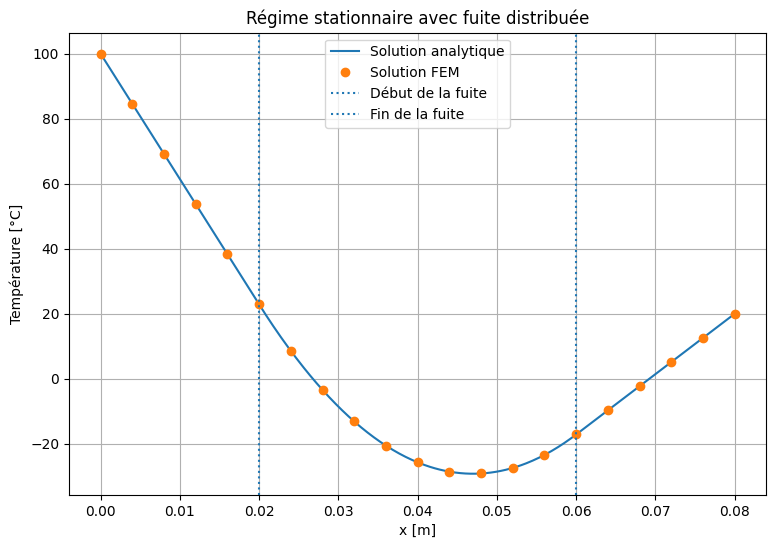

In [ ]:
# ============================================================
# COMPARAISON FEM / SOLUTION ANALYTIQUE
# ============================================================

x_fine = np.linspace(x_nodes[0], x_nodes[-1], 500)

T_analytic_dist_fine, _ = analytical_distributed_leak_solution(
    x=x_fine - x_nodes[0],
    L=L_eff,
    Tinf=Tinf,
    Tsup=Tsup,
    alpha=alpha_fem,
    q_dist=q_dist,
    x_a=x_a - x_nodes[0],
    x_b=x_b - x_nodes[0]
)

T_analytic_dist_nodes, _ = analytical_distributed_leak_solution(
    x=x_nodes - x_nodes[0],
    L=L_eff,
    Tinf=Tinf,
    Tsup=Tsup,
    alpha=alpha_fem,
    q_dist=q_dist,
    x_a=x_a - x_nodes[0],
    x_b=x_b - x_nodes[0]
)

plt.figure(figsize=(9, 6))

plt.plot(
    x_fine,
    T_analytic_dist_fine,
    label="Solution analytique"
)

plt.plot(
    x_nodes,
    T_fem_dist,
    marker="o",
    linestyle="",
    label="Solution FEM"
)

plt.axvline(x_a, linestyle=":", label="Début de la fuite")
plt.axvline(x_b, linestyle=":", label="Fin de la fuite")

plt.xlabel("x [m]")
plt.ylabel("Température [°C]")
plt.title("Régime stationnaire avec fuite distribuée")
plt.grid(True)
plt.legend()
plt.show()

## Diagnostic numérique de la solution FEM

On quantifie l’écart entre la solution FEM et la solution analytique aux nœuds de la maille :

$$
e_i
=
T_{\mathrm{FEM}}(x_i)
-
T_{\mathrm{analytique}}(x_i)
$$

On calcule ensuite plusieurs indicateurs d’erreur.

L’erreur absolue maximale est :

$$
e_{\max}
=
\max_i |e_i|
$$

La racine de l’erreur quadratique moyenne est :

$$
\mathrm{RMSE}
=
\sqrt{
\frac{1}{N}
\sum_{i=1}^{N}
e_i^2
}
$$

On calcule aussi le coefficient de détermination :

$$
R^2
=
1
-
\frac{
\sum_i
\left(
T_{\mathrm{FEM}}(x_i)-T_{\mathrm{analytique}}(x_i)
\right)^2
}{
\sum_i
\left(
T_{\mathrm{analytique}}(x_i)-\overline{T}_{\mathrm{analytique}}
\right)^2
}
$$

Une valeur de $R^2$ proche de 1 indique que la solution FEM reproduit correctement la solution analytique.

In [ ]:
# ============================================================
# DIAGNOSTIC NUMÉRIQUE
# ============================================================

error_dist = T_fem_dist - T_analytic_dist_nodes

ss_res = np.sum(error_dist**2)
ss_tot = np.sum((T_analytic_dist_nodes - np.mean(T_analytic_dist_nodes))**2)

R2_dist = 1.0 - ss_res / ss_tot

diagnostic_dist_df = pd.DataFrame({
    "node": np.arange(len(x_nodes)),
    "x_m": x_nodes,
    "T_FEM_C": T_fem_dist,
    "T_analytique_C": T_analytic_dist_nodes,
    "erreur_C": error_dist,
    "abs_erreur_C": np.abs(error_dist)
})

display(diagnostic_dist_df)

print("Diagnostic FEM vs analytique :")
print(f"R²                  = {R2_dist:.10f}")
print(f"Erreur max abs [°C] = {np.max(np.abs(error_dist)):.6e}")
print(f"Erreur moyenne [°C] = {np.mean(error_dist):.6e}")
print(f"RMSE [°C]           = {np.sqrt(np.mean(error_dist**2)):.6e}")

,node,x_m,T_FEM_C,T_analytique_C,erreur_C,abs_erreur_C
0,0,0.000,100.000000,100.000000,0.000000e+00,0.000000e+00
1,1,0.004,84.571429,84.571429,0.000000e+00,0.000000e+00
2,2,0.008,69.142857,69.142857,0.000000e+00,0.000000e+00
3,3,0.012,53.714286,53.714286,0.000000e+00,0.000000e+00
4,4,0.016,38.285714,38.285714,7.105427e-15,7.105427e-15
5,5,0.020,22.857143,22.857143,1.065814e-14,1.065814e-14
6,6,0.024,8.571429,8.571429,1.776357e-15,1.776357e-15
7,7,0.028,-3.428571,-3.428571,-2.575717e-14,2.575717e-14
8,8,0.032,-13.142857,-13.142857,-1.598721e-14,1.598721e-14
9,9,0.036,-20.571429,-20.571429,-7.105427e-15,7.105427e-15


Diagnostic FEM vs analytique :
R²                  = 1.0000000000
Erreur max abs [°C] = 3.552714e-14
Erreur moyenne [°C] = -2.199299e-15
RMSE [°C]           = 1.350332e-14


## Diagnostic de l’intensité de la fuite distribuée

Ce bloc permet de vérifier si la fuite distribuée a bien un effet mesurable sur la solution stationnaire.

On commence par construire la solution de référence sans fuite. Dans ce cas, le problème est simplement :

$$
\frac{d^2T}{dx^2}=0
$$

avec les conditions aux limites :

$$
T(0)=T_{\mathrm{inf}}
$$

$$
T(L)=T_{\mathrm{sup}}
$$

La solution sans fuite est donc une droite :

$$
T_{\mathrm{sans\ fuite}}(x)
=
T_{\mathrm{inf}}
+
\frac{T_{\mathrm{sup}}-T_{\mathrm{inf}}}{L}x
$$

On compare ensuite la solution avec fuite à cette solution de référence. Pour la solution analytique, on définit :

$$
\Delta T_{\mathrm{analytique}}(x)
=
T_{\mathrm{analytique}}(x)
-
T_{\mathrm{sans\ fuite}}(x)
$$

et pour la solution éléments finis :

$$
\Delta T_{\mathrm{FEM}}(x)
=
T_{\mathrm{FEM}}(x)
-
T_{\mathrm{sans\ fuite}}(x)
$$

Ces écarts permettent de mesurer directement l’effet de la fuite distribuée sur le profil de température.

Le rapport important est :

$$
\frac{q_{\mathrm{dist}}}{\alpha}
$$

car, dans la zone de fuite, l’équation stationnaire donne :

$$
\frac{d^2T}{dx^2}
=
\frac{q_{\mathrm{dist}}}{\alpha}
$$

Ainsi, ce rapport contrôle directement la courbure de la solution dans l’intervalle :

$$
[x_a,x_b]
$$

Le bloc vérifie aussi l’assemblage du vecteur de fuite. Comme les fonctions de forme vérifient la propriété de partition de l’unité :

$$
\sum_l N_l(x)=1
$$

on doit avoir :

$$
\sum_l F_l
=
-q_{\mathrm{dist}}
\int_{x_a}^{x_b}
\sum_l N_l(x)\,dx
$$

donc :

$$
\sum_l F_l
=
-q_{\mathrm{dist}}
\int_{x_a}^{x_b}1\,dx
$$

Finalement :

$$
\sum_l F_l
=
-q_{\mathrm{dist}}(x_b-x_a)
$$

La comparaison entre la somme numérique du vecteur assemblé et cette valeur théorique permet de vérifier que la fuite distribuée a bien été intégrée sur la bonne zone.

In [ ]:
# ============================================================
# DIAGNOSTIC DE L'INTENSITÉ DE LA FUITE
# ============================================================

T_no_leak = Tinf + (Tsup - Tinf) * (x_nodes - x_nodes[0]) / L_eff

delta_analytic = T_analytic_dist_nodes - T_no_leak
delta_fem = T_fem_dist - T_no_leak

print("Diagnostic de la fuite distribuée :")
print(f"q_dist              = {q_dist:.6e}")
print(f"alpha_fem           = {alpha_fem:.6e}")
print(f"q_dist / alpha_fem  = {q_dist / alpha_fem:.6e}")
print(f"max |T_analytique - T_sans_fuite| = {np.max(np.abs(delta_analytic)):.6e} °C")
print(f"max |T_FEM - T_sans_fuite|        = {np.max(np.abs(delta_fem)):.6e} °C")

print("\nVérification du vecteur F_dist :")
print(f"Somme F_dist              = {np.sum(F_dist):.6e}")
print(f"Valeur théorique attendue = {-q_dist * (x_b - x_a):.6e}")

Diagnostic de la fuite distribuée :
q_dist              = 1.000000e-01
alpha_fem           = 7.000000e-07
q_dist / alpha_fem  = 1.428571e+05
max |T_analytique - T_sans_fuite| = 8.571429e+01 °C
max |T_FEM - T_sans_fuite|        = 8.571429e+01 °C

Vérification du vecteur F_dist :
Somme F_dist              = -4.000000e-03
Valeur théorique attendue = -4.000000e-03


## Comparaison entre charge ponctuelle et fuite distribuée

On compare maintenant deux façons de modéliser une perte thermique :

1. une perte ponctuelle localisée en un point $x_c$ ;
2. une perte distribuée sur un intervalle $[x_a,x_b]$.

Le cas ponctuel est décrit par :

$$
0=\alpha \frac{d^2T}{dx^2}
-
s_{\mathrm{point}}\delta(x-x_c)
$$

Le cas distribué est décrit par :

$$
0=\alpha \frac{d^2T}{dx^2}
-
q_{\mathrm{dist}}\chi_{[x_a,x_b]}(x)
$$

où :

$$
\chi_{[x_a,x_b]}(x)
=
\begin{cases}
1, & x_a\leq x\leq x_b\\
0, & \text{ailleurs}
\end{cases}
$$

Pour que les deux modèles soient comparables, il ne faut pas imposer directement :

$$
s_{\mathrm{point}}=q_{\mathrm{dist}}
$$

car ces deux grandeurs ne représentent pas la même chose. La charge ponctuelle représente une intensité totale concentrée en un point, alors que la fuite distribuée représente une intensité par unité de longueur.

La condition correcte de comparaison consiste à égaler les pertes totales :

$$
s_{\mathrm{point}}
=
\int_{x_a}^{x_b}
q_{\mathrm{dist}}\,dx
$$

Donc :

$$
s_{\mathrm{point}}
=
q_{\mathrm{dist}}(x_b-x_a)
$$

On en déduit l’intensité distribuée équivalente :

$$
q_{\mathrm{dist,eq}}
=
\frac{s_{\mathrm{point}}}{x_b-x_a}
$$

Ainsi, les deux modèles retirent la même quantité totale de chaleur, mais de manière différente : l’un de façon localisée, l’autre de façon répartie.

In [ ]:
# ============================================================
# PARAMÈTRES DE COMPARAISON :
# CHARGE PONCTUELLE VS FUITE DISTRIBUÉE
# ============================================================

L_leak = x_b - x_a

if L_leak <= 0:
    raise ValueError("La longueur de la zone distribuée doit être positive.")

# Condition de comparabilité :
# perte totale ponctuelle = perte totale distribuée
#
#   s_point = q_dist_eq * (x_b - x_a)
#
q_dist_eq = s_point / L_leak

print("Comparaison ponctuelle vs distribuée")
print(f"x_c        = {x_c:.6e} m")
print(f"x_a        = {x_a:.6e} m")
print(f"x_b        = {x_b:.6e} m")
print(f"L_leak     = {L_leak:.6e} m")
print(f"s_point    = {s_point:.6e}")
print(f"q_dist_eq  = {q_dist_eq:.6e}")

print("\nVérification de l'équivalence des pertes totales :")
print(f"Perte ponctuelle totale     = {s_point:.6e}")
print(f"Perte distribuée totale     = {q_dist_eq * (x_b - x_a):.6e}")

Comparaison ponctuelle vs distribuée
x_c        = 4.000000e-02 m
x_a        = 2.000000e-02 m
x_b        = 6.000000e-02 m
L_leak     = 4.000000e-02 m
s_point    = 4.000000e-03
q_dist_eq  = 1.000000e-01

Vérification de l'équivalence des pertes totales :
Perte ponctuelle totale     = 4.000000e-03
Perte distribuée totale     = 4.000000e-03


## Résolution FEM avec fuite distribuée équivalente

On construit maintenant le cas distribué équivalent au cas ponctuel.

La matrice de rigidité reste la même que dans les cas précédents :

$$
K_{lm}
=
\int_0^L
\frac{dN_l}{dx}
\frac{dN_m}{dx}
\,dx
$$

Le système stationnaire à résoudre est :

$$
\alpha KT=F_{\mathrm{dist,eq}}
$$

avec :

$$
F_l^{\mathrm{dist,eq}}
=
-q_{\mathrm{dist,eq}}
\int_{x_a}^{x_b}
N_l(x)\,dx
$$

La seule différence par rapport au cas ponctuel se trouve dans le second membre. Dans le cas ponctuel, la charge est concentrée en $x_c$ :

$$
F_l^{\mathrm{point}}
=
-s_{\mathrm{point}}N_l(x_c)
$$

Dans le cas distribué, la charge est répartie sur l’intervalle $[x_a,x_b]$ :

$$
F_l^{\mathrm{dist,eq}}
=
-q_{\mathrm{dist,eq}}
\int_{x_a}^{x_b}
N_l(x)\,dx
$$

Le choix :

$$
q_{\mathrm{dist,eq}}
=
\frac{s_{\mathrm{point}}}{x_b-x_a}
$$

garantit que les deux pertes ont la même intensité totale.

In [ ]:
# ============================================================
# SOLUTION FEM STATIONNAIRE : FUITE DISTRIBUÉE ÉQUIVALENTE
# ============================================================

F_dist_eq = assemble_distributed_load_vector_p1(
    x_nodes=x_nodes,
    x_a=x_a,
    x_b=x_b,
    q_dist=q_dist_eq
)

if "K_global" in globals() and K_global.shape == (len(x_nodes), len(x_nodes)):
    K_dist_eq = K_global.copy()
else:
    K_dist_eq, _ = assemble_global_system(x_nodes)

T_fem_dist_eq, K_reduced_dist_eq, F_reduced_dist_eq, free_nodes_dist_eq = solve_dirichlet_strong(
    alpha_fem * K_dist_eq,
    F_dist_eq,
    Tinf,
    Tsup
)

print("Résolution FEM distribuée équivalente terminée.")
print(f"T_min FEM distribué = {np.min(T_fem_dist_eq):.6f} °C")
print(f"T_max FEM distribué = {np.max(T_fem_dist_eq):.6f} °C")

Résolution FEM distribuée équivalente terminée.
T_min FEM distribué = -29.142857 °C
T_max FEM distribué = 100.000000 °C


## Solution analytique de la fuite distribuée équivalente

On calcule aussi la solution analytique correspondant à la fuite distribuée équivalente.

Le problème est :

$$
0=\alpha \frac{d^2T}{dx^2}
-
q_{\mathrm{dist,eq}}\chi_{[x_a,x_b]}(x)
$$

Dans les zones sans fuite :

$$
0\leq x<x_a
$$

et :

$$
x_b<x\leq L
$$

on a :

$$
\frac{d^2T}{dx^2}=0
$$

La solution y est donc linéaire.

Dans la zone de fuite :

$$
x_a\leq x\leq x_b
$$

on a :

$$
\frac{d^2T}{dx^2}
=
\frac{q_{\mathrm{dist,eq}}}{\alpha}
$$

La solution y est donc quadratique.

La solution analytique est donc composée de trois morceaux :

$$
T(x)
=
\begin{cases}
T_1(x), & 0\leq x\leq x_a\\
T_2(x), & x_a\leq x\leq x_b\\
T_3(x), & x_b\leq x\leq L
\end{cases}
$$

Cette solution est comparée à la solution FEM afin de vérifier que le vecteur de charge distribuée équivalente est correctement assemblé.

In [ ]:
# ============================================================
# SOLUTION ANALYTIQUE : FUITE DISTRIBUÉE ÉQUIVALENTE
# ============================================================

T_analytic_dist_eq_nodes, constants_dist_eq = analytical_distributed_leak_solution(
    x=x_nodes - x_nodes[0],
    L=L_eff,
    Tinf=Tinf,
    Tsup=Tsup,
    alpha=alpha_fem,
    q_dist=q_dist_eq,
    x_a=x_a - x_nodes[0],
    x_b=x_b - x_nodes[0]
)

x_fine = np.linspace(x_nodes[0], x_nodes[-1], 500)

T_analytic_dist_eq_fine, _ = analytical_distributed_leak_solution(
    x=x_fine - x_nodes[0],
    L=L_eff,
    Tinf=Tinf,
    Tsup=Tsup,
    alpha=alpha_fem,
    q_dist=q_dist_eq,
    x_a=x_a - x_nodes[0],
    x_b=x_b - x_nodes[0]
)

## Comparaison des profils de température

On compare maintenant les profils de température obtenus avec les deux modèles de perte :

$$
\text{charge ponctuelle}
$$

et :

$$
\text{fuite distribuée équivalente}
$$

Les deux cas sont comparables car leurs pertes totales sont identiques :

$$
s_{\mathrm{point}}
=
q_{\mathrm{dist,eq}}(x_b-x_a)
$$

Le cas ponctuel vérifie :

$$
0=\alpha \frac{d^2T}{dx^2}
-
s_{\mathrm{point}}\delta(x-x_c)
$$

Le cas distribué équivalent vérifie :

$$
0=\alpha \frac{d^2T}{dx^2}
-
q_{\mathrm{dist,eq}}\chi_{[x_a,x_b]}(x)
$$

La solution ponctuelle est composée de deux segments linéaires avec un changement de pente en $x_c$.

La solution distribuée est plus régulière : elle est linéaire en dehors de la zone $[x_a,x_b]$ et quadratique à l’intérieur de cette zone.

Sur la figure, on trace également la solution sans fuite :

$$
T_{\mathrm{sans\ fuite}}(x)
=
T_{\mathrm{inf}}
+
\frac{T_{\mathrm{sup}}-T_{\mathrm{inf}}}{L}x
$$

Cette courbe sert de référence pour visualiser l’effet de chaque type de perte.

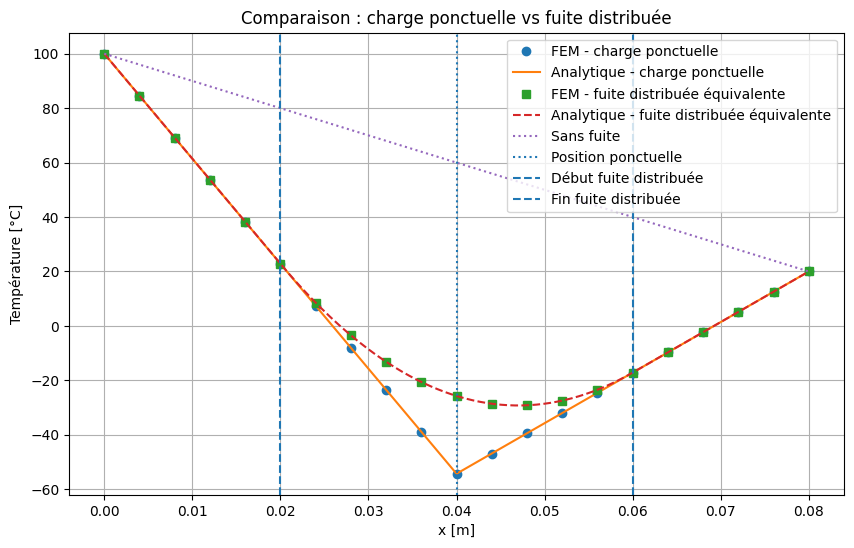

In [ ]:
# ============================================================
# COMPARAISON DES PROFILS :
# CHARGE PONCTUELLE VS FUITE DISTRIBUÉE
# ============================================================

T_no_leak = Tinf + (Tsup - Tinf) * (x_nodes - x_nodes[0]) / L_eff

plt.figure(figsize=(10, 6))

# Cas ponctuel
plt.plot(
    x_nodes,
    T_fem_point_stationary,
    "o",
    label="FEM - charge ponctuelle"
)

plt.plot(
    x_fine,
    T_analytic_point_fine,
    "-",
    label="Analytique - charge ponctuelle"
)

# Cas distribué équivalent
plt.plot(
    x_nodes,
    T_fem_dist_eq,
    "s",
    label="FEM - fuite distribuée équivalente"
)

plt.plot(
    x_fine,
    T_analytic_dist_eq_fine,
    "--",
    label="Analytique - fuite distribuée équivalente"
)

# Référence sans fuite
plt.plot(
    x_nodes,
    T_no_leak,
    ":",
    label="Sans fuite"
)

plt.axvline(x_c, linestyle=":", label="Position ponctuelle")
plt.axvline(x_a, linestyle="--", label="Début fuite distribuée")
plt.axvline(x_b, linestyle="--", label="Fin fuite distribuée")

plt.xlabel("x [m]")
plt.ylabel("Température [°C]")
plt.title("Comparaison : charge ponctuelle vs fuite distribuée")
plt.grid(True)
plt.legend()
plt.show()

## Comparaison des écarts au cas sans fuite

Pour mieux visualiser l’effet propre de chaque perte thermique, on compare les écarts par rapport au cas sans fuite.

On définit d’abord la solution de référence sans perte :

$$
T_{\mathrm{sans\ fuite}}(x)
=
T_{\mathrm{inf}}
+
\frac{T_{\mathrm{sup}}-T_{\mathrm{inf}}}{L}x
$$

Puis on définit l’écart de température pour le cas ponctuel :

$$
\Delta T_{\mathrm{point}}(x)
=
T_{\mathrm{point}}(x)
-
T_{\mathrm{sans\ fuite}}(x)
$$

et pour le cas distribué équivalent :

$$
\Delta T_{\mathrm{dist}}(x)
=
T_{\mathrm{dist}}(x)
-
T_{\mathrm{sans\ fuite}}(x)
$$

Ces écarts permettent d’observer uniquement l’effet de la perte thermique, sans être dominé par la pente globale imposée par les conditions aux limites.

Comme les températures aux frontières sont imposées dans tous les cas :

$$
T(0)=T_{\mathrm{inf}}
$$

$$
T(L)=T_{\mathrm{sup}}
$$

on a nécessairement :

$$
\Delta T(0)=0
$$

et :

$$
\Delta T(L)=0
$$

La charge ponctuelle produit un écart plus anguleux, avec un minimum localisé autour de $x_c$. La fuite distribuée produit un écart plus régulier, car la perte est répartie sur l’intervalle $[x_a,x_b]$.

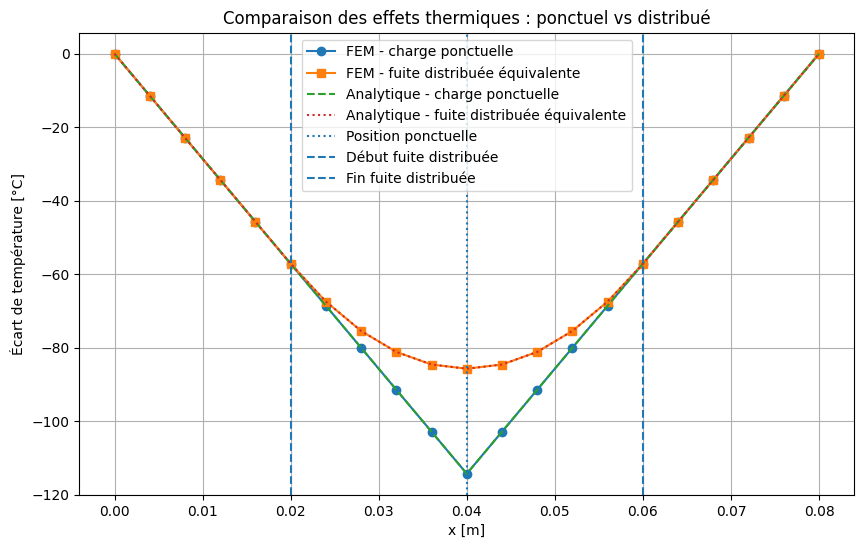

In [ ]:
# ============================================================
# COMPARAISON DES ÉCARTS AU CAS SANS FUITE
# ============================================================

delta_point_fem = T_fem_point_stationary - T_no_leak
delta_dist_fem = T_fem_dist_eq - T_no_leak

delta_point_analytic = T_analytic_point_nodes - T_no_leak
delta_dist_analytic = T_analytic_dist_eq_nodes - T_no_leak

plt.figure(figsize=(10, 6))

plt.plot(
    x_nodes,
    delta_point_fem,
    "o-",
    label="FEM - charge ponctuelle"
)

plt.plot(
    x_nodes,
    delta_dist_fem,
    "s-",
    label="FEM - fuite distribuée équivalente"
)

plt.plot(
    x_nodes,
    delta_point_analytic,
    "--",
    label="Analytique - charge ponctuelle"
)

plt.plot(
    x_nodes,
    delta_dist_analytic,
    ":",
    label="Analytique - fuite distribuée équivalente"
)

plt.axvline(x_c, linestyle=":", label="Position ponctuelle")
plt.axvline(x_a, linestyle="--", label="Début fuite distribuée")
plt.axvline(x_b, linestyle="--", label="Fin fuite distribuée")

plt.xlabel("x [m]")
plt.ylabel("Écart de température [°C]")
plt.title("Comparaison des effets thermiques : ponctuel vs distribué")
plt.grid(True)
plt.legend()
plt.show()

## Diagnostic comparatif entre charge ponctuelle et fuite distribuée

On rassemble les résultats des deux modèles afin de comparer quantitativement leurs effets.

La condition d’équivalence utilisée est :

$$
s_{\mathrm{point}}
=
q_{\mathrm{dist,eq}}(x_b-x_a)
$$

On compare notamment les écarts au cas sans fuite :

$$
\Delta T_{\mathrm{point}}(x)
=
T_{\mathrm{point}}(x)
-
T_{\mathrm{sans\ fuite}}(x)
$$

et :

$$
\Delta T_{\mathrm{dist}}(x)
=
T_{\mathrm{dist}}(x)
-
T_{\mathrm{sans\ fuite}}(x)
$$

Le minimum de ces écarts indique l’intensité maximale de l’effet thermique :

$$
\min_x \Delta T_{\mathrm{point}}(x)
$$

et :

$$
\min_x \Delta T_{\mathrm{dist}}(x)
$$

Même si les deux pertes ont la même intensité totale, leurs effets locaux ne sont pas identiques. La charge ponctuelle concentre toute la perte en un point, ce qui génère un profil avec un changement de pente marqué. La fuite distribuée répartit la même perte totale sur une longueur finie, ce qui produit une déformation plus douce du profil de température.

In [ ]:
# ============================================================
# DIAGNOSTIC COMPARATIF
# ============================================================

comparison_df = pd.DataFrame({
    "x_m": x_nodes,
    "T_point_FEM_C": T_fem_point_stationary,
    "T_point_analytic_C": T_analytic_point_nodes,
    "T_dist_FEM_C": T_fem_dist_eq,
    "T_dist_analytic_C": T_analytic_dist_eq_nodes,
    "delta_point_vs_no_leak_C": delta_point_fem,
    "delta_dist_vs_no_leak_C": delta_dist_fem
})

display(comparison_df)

print("Comparaison des amplitudes maximales :")
print(f"min(delta_point_fem) = {np.min(delta_point_fem):.6e} °C")
print(f"min(delta_dist_fem)  = {np.min(delta_dist_fem):.6e} °C")

print("\nPertes totales :")
print(f"Ponctuelle                  = {s_point:.6e}")
print(f"Distribuée équivalente      = {q_dist_eq * (x_b - x_a):.6e}")

,x_m,T_point_FEM_C,T_point_analytic_C,T_dist_FEM_C,T_dist_analytic_C,delta_point_vs_no_leak_C,delta_dist_vs_no_leak_C
0,0.000,100.000000,100.000000,100.000000,100.000000,0.000000,0.000000
1,0.004,84.571429,84.571429,84.571429,84.571429,-11.428571,-11.428571
2,0.008,69.142857,69.142857,69.142857,69.142857,-22.857143,-22.857143
3,0.012,53.714286,53.714286,53.714286,53.714286,-34.285714,-34.285714
4,0.016,38.285714,38.285714,38.285714,38.285714,-45.714286,-45.714286
5,0.020,22.857143,22.857143,22.857143,22.857143,-57.142857,-57.142857
6,0.024,7.428571,7.428571,8.571429,8.571429,-68.571429,-67.428571
7,0.028,-8.000000,-8.000000,-3.428571,-3.428571,-80.000000,-75.428571
8,0.032,-23.428571,-23.428571,-13.142857,-13.142857,-91.428571,-81.142857
9,0.036,-38.857143,-38.857143,-20.571429,-20.571429,-102.857143,-84.571429


Comparaison des amplitudes maximales :
min(delta_point_fem) = -1.142857e+02 °C
min(delta_dist_fem)  = -8.571429e+01 °C

Pertes totales :
Ponctuelle                  = 4.000000e-03
Distribuée équivalente      = 4.000000e-03


## Paramètres du cas transitoire avec fuite distribuée

On étudie maintenant le problème transitoire avec une perte distribuée sur une zone de l’échantillon :

$$
x\in[x_a,x_b]
$$

L’équation physique de départ est :

$$
\rho c_p \frac{\partial T}{\partial t}
=
\lambda \frac{\partial^2 T}{\partial x^2}
-
q_{\mathrm{dist}}\chi_{[x_a,x_b]}(x)
$$

où $q_{\mathrm{dist}}$ représente l’intensité physique de la perte distribuée, et où :

$$
\chi_{[x_a,x_b]}(x)
=
\begin{cases}
1, & x_a\leq x\leq x_b\\
0, & \text{ailleurs}
\end{cases}
$$

En divisant par la capacité thermique volumique $\rho c_p$, on obtient :

$$
\frac{\partial T}{\partial t}
=
\alpha \frac{\partial^2 T}{\partial x^2}
-
s_{\mathrm{dist}}\chi_{[x_a,x_b]}(x)
$$

avec :

$$
\alpha=\frac{\lambda}{\rho c_p}
$$

et :

$$
s_{\mathrm{dist}}
=
\frac{q_{\mathrm{dist}}}{\rho c_p}
$$

Dans le code, $q_{\mathrm{dist}}$ a déjà été défini dans le cas stationnaire. On construit donc seulement la quantité normalisée $s_{\mathrm{dist}}$, qui est celle utilisée dans l’équation transitoire.

In [ ]:
# ============================================================
# PARAMÈTRES DU CAS TRANSITOIRE AVEC FUITE DISTRIBUÉE
# ============================================================

L_eff = x_nodes[-1] - x_nodes[0]
#rho = 2068.6
#cp = 720
alpha_fem = float(a)

#rho_cp = rho * cp

# Intensité normalisée de la perte distribuée :
# s_dist = q_dist / (rho cp)
s_dist = q_dist

print("Paramètres du cas transitoire avec fuite distribuée :")
print(f"L_eff     = {L_eff:.6e} m")
print(f"alpha_fem = {alpha_fem:.6e}")
print(f"rho       = {rho:.6e}")
print(f"cp        = {cp:.6e}")
print(f"rho_cp    = {rho_cp:.6e}")
print(f"q_dist    = {q_dist:.6e}")
print(f"s_dist    = {s_dist:.6e}")
print(f"x_a       = {x_a:.6e} m")
print(f"x_b       = {x_b:.6e} m")

Paramètres du cas transitoire avec fuite distribuée :
L_eff     = 8.000000e-02 m
alpha_fem = 7.000000e-07


NameError: name 'rho' is not defined

## Assemblage du vecteur de fuite distribuée transitoire

Le problème transitoire discrétisé s’écrit sous la forme :

$$
M\dot{T}+\alpha KT=F_{\mathrm{dist}}
$$

La matrice de masse $M$ et la matrice de rigidité $K$ sont les mêmes que dans les simulations transitoires précédentes. La nouvelle contribution est le vecteur de fuite distribuée :

$$
F_l^{\mathrm{dist}}
=
-s_{\mathrm{dist}}
\int_{x_a}^{x_b}
N_l(x)\,dx
$$

La fonction utilisée pour assembler ce vecteur est la même que dans le cas stationnaire avec fuite distribuée. Même si l’argument de la fonction s’appelle `q_dist`, on lui passe ici la valeur normalisée :

$$
s_{\mathrm{dist}}
=
\frac{q_{\mathrm{dist}}}{\rho c_p}
$$

car c’est cette quantité qui apparaît dans l’équation transitoire normalisée.

On vérifie également la somme du vecteur assemblé. Comme les fonctions de forme vérifient :

$$
\sum_l N_l(x)=1
$$

on doit obtenir :

$$
\sum_l F_l^{\mathrm{dist}}
=
-s_{\mathrm{dist}}(x_b-x_a)
$$

In [ ]:
# ============================================================
# VECTEUR DE FUITE DISTRIBUÉE POUR LE CAS TRANSITOIRE
# ============================================================

F_dist_transient = assemble_distributed_load_vector_p1(
    x_nodes=x_nodes,
    x_a=x_a,
    x_b=x_b,
    q_dist=s_dist
)

print("Vecteur de fuite distribuée transitoire assemblé.")

print("\nSomme du vecteur F_dist_transient :")
print(f"Somme numérique = {np.sum(F_dist_transient):.6e}")
print(f"Valeur attendue = {-s_dist * (x_b - x_a):.6e}")

## Régime stationnaire associé au problème transitoire

La solution transitoire doit converger vers un régime stationnaire lorsque le temps devient suffisamment grand.

Le système transitoire est :

$$
M\dot{T}+\alpha KT=F_{\mathrm{dist}}
$$

Au régime stationnaire, on a :

$$
\dot{T}=0
$$

Donc le système devient :

$$
\alpha KT=F_{\mathrm{dist}}
$$

Ce bloc calcule ce profil stationnaire associé à la même fuite distribuée que celle utilisée dans le problème transitoire.

On calcule également la solution analytique stationnaire correspondante. Cette solution est composée de trois zones :

$$
T(x)
=
\begin{cases}
T_1(x), & 0\leq x\leq x_a\\
T_2(x), & x_a\leq x\leq x_b\\
T_3(x), & x_b\leq x\leq L
\end{cases}
$$

Dans les zones sans fuite, la solution est linéaire. Dans la zone de fuite, elle est quadratique, car :

$$
\frac{d^2T}{dx^2}
=
\frac{s_{\mathrm{dist}}}{\alpha}
$$

Ce profil stationnaire servira de référence pour vérifier la convergence de la simulation transitoire.

In [ ]:
# ============================================================
# RÉGIME STATIONNAIRE ASSOCIÉ AU CAS TRANSITOIRE
# ============================================================

T_stationary_dist_transient, K_red_dist_tr, F_red_dist_tr, free_nodes_dist_tr = solve_dirichlet_strong(
    alpha_fem * K_transient,
    F_dist_transient,
    Tinf,
    Tsup
)

T_analytic_dist_transient_nodes, constants_dist_transient = analytical_distributed_leak_solution(
    x=x_nodes - x_nodes[0],
    L=L_eff,
    Tinf=Tinf,
    Tsup=Tsup,
    alpha=alpha_fem,
    q_dist=s_dist,
    x_a=x_a - x_nodes[0],
    x_b=x_b - x_nodes[0]
)

print("Régime stationnaire associé calculé.")
print(f"T_min stationnaire = {np.min(T_stationary_dist_transient):.6f} °C")
print(f"T_max stationnaire = {np.max(T_stationary_dist_transient):.6f} °C")

error_stationary = T_stationary_dist_transient - T_analytic_dist_transient_nodes

print("\nVérification stationnaire FEM vs analytique :")
print(f"Erreur max abs = {np.max(np.abs(error_stationary)):.6e} °C")
print(f"RMSE           = {np.sqrt(np.mean(error_stationary**2)):.6e} °C")

## Simulation transitoire avec fuite distribuée

On résout maintenant le problème transitoire :

$$
M\dot{T}+\alpha KT=F_{\mathrm{dist}}
$$

avec les conditions de Dirichlet imposées aux deux extrémités :

$$
T(0,t)=T_{\mathrm{inf}}
$$

$$
T(L,t)=T_{\mathrm{sup}}
$$

On réutilise la fonction déjà définie pour le cas transitoire avec charge constante, car cette fonction résout en réalité un système général de la forme :

$$
M\dot{T}+\alpha KT=F
$$

Dans le cas présent, le second membre est simplement :

$$
F=F_{\mathrm{dist}}
$$

Le système réduit aux nœuds libres est :

$$
M_{ff}\dot{T}_f
=
F_f^{\mathrm{dist}}
-
\alpha K_{ff}T_f
-
\alpha K_{fd}T_d
$$

où $T_d$ contient les températures imposées aux frontières.

Avec Euler explicite, la mise à jour temporelle est :

$$
T_f^{n+1}
=
T_f^n
+
\Delta t
M_{ff}^{-1}
\left(
F_f^{\mathrm{dist}}
-
\alpha K_{ff}T_f^n
-
\alpha K_{fd}T_d
\right)
$$

In [ ]:
# ============================================================
# SIMULATION TRANSITOIRE AVEC FUITE DISTRIBUÉE
# ============================================================

saved_profiles_dist_loss, time_history_dist_loss, center_temperature_history_dist_loss, dt_eff_dist_loss = simulate_heat_transient_euler_with_point_load(
    M=M_transient,
    K=K_transient,
    f_point=F_dist_transient,
    x_nodes=x_nodes,
    a=alpha_fem,
    Tinf=Tinf,
    Tsup=Tsup,
    t_final=t_final,
    dt=dt,
    times_to_save=times_to_plot
)

print("Simulation transitoire avec fuite distribuée terminée.")
print(f"dt effectif = {dt_eff_dist_loss:.6e} s")
print(f"nombre de pas = {len(time_history_dist_loss)-1}")

## Visualisation des profils transitoires

On trace les profils de température obtenus à différents instants de la simulation.

Le profil initial correspond à l’état imposé au début du calcul. Ensuite, la température évolue sous l’effet de la diffusion thermique et de la fuite distribuée.

Le régime stationnaire associé est également tracé :

$$
\alpha KT=F_{\mathrm{dist}}
$$

Ce profil représente la limite attendue lorsque :

$$
t\rightarrow\infty
$$

Les lignes verticales indiquent les limites de la zone de fuite :

$$
x=x_a
$$

et :

$$
x=x_b
$$

La simulation est cohérente si les profils transitoires se rapprochent progressivement du régime stationnaire avec fuite distribuée.

In [ ]:
# ============================================================
# PROFILS TRANSITOIRES AVEC FUITE DISTRIBUÉE
# ============================================================

saved_profiles_dist_loss_sorted = sorted(
    saved_profiles_dist_loss,
    key=lambda item: item[0]
)

plt.figure(figsize=(9, 6))

for time_value, T_profile in saved_profiles_dist_loss_sorted:
    plt.plot(
        x_nodes,
        T_profile,
        marker="o",
        label=f"t = {time_value:.1f} s"
    )

plt.plot(
    x_nodes,
    T_stationary_dist_transient,
    "--",
    label="Régime stationnaire avec fuite"
)

plt.axvline(x_a, linestyle=":", label="Début de la fuite")
plt.axvline(x_b, linestyle=":", label="Fin de la fuite")

plt.xlabel("x [m]")
plt.ylabel("Température [°C]")
plt.title("Évolution transitoire avec fuite distribuée")
plt.grid(True)
plt.legend()
plt.show()

## Évolution temporelle de la température au centre

On observe maintenant l’évolution de la température au centre de l’échantillon.

Le point suivi est proche de :

$$
x=\frac{L}{2}
$$

Cette grandeur permet de visualiser simplement la convergence temporelle de la simulation.

La température centrale transitoire est comparée à la valeur centrale du régime stationnaire :

$$
T_{\mathrm{stationnaire}}\left(\frac{L}{2}\right)
$$

Si la simulation converge correctement, alors :

$$
T_{\mathrm{centre}}(t)
\longrightarrow
T_{\mathrm{stationnaire}}\left(\frac{L}{2}\right)
$$

lorsque le temps augmente.

In [ ]:
# ============================================================
# ÉVOLUTION DE LA TEMPÉRATURE AU CENTRE
# ============================================================

center_node = np.argmin(np.abs(x_nodes - (x_nodes[0] + L_eff / 2.0)))

plt.figure(figsize=(9, 6))

plt.plot(
    time_history_dist_loss,
    center_temperature_history_dist_loss,
    label="Centre - transitoire avec fuite distribuée"
)

plt.axhline(
    T_stationary_dist_transient[center_node],
    linestyle="--",
    label="Centre - régime stationnaire"
)

plt.xlabel("Temps [s]")
plt.ylabel("Température au centre [°C]")
plt.title("Convergence de la température centrale")
plt.grid(True)
plt.legend()
plt.show()

## Diagnostic de convergence vers le régime stationnaire

On quantifie maintenant l’écart entre chaque profil transitoire sauvegardé et le profil stationnaire associé.

Pour chaque temps $t_n$, on définit l’erreur nodale :

$$
e_i(t_n)
=
T_i(t_n)
-
T_{i,\mathrm{stationnaire}}
$$

On calcule ensuite plusieurs indicateurs.

L’erreur absolue maximale est :

$$
e_{\max}(t_n)
=
\max_i |e_i(t_n)|
$$

L’erreur absolue moyenne est :

$$
e_{\mathrm{moy}}(t_n)
=
\frac{1}{N}
\sum_{i=1}^{N}
|e_i(t_n)|
$$

La racine de l’erreur quadratique moyenne est :

$$
\mathrm{RMSE}(t_n)
=
\sqrt{
\frac{1}{N}
\sum_{i=1}^{N}
e_i(t_n)^2
}
$$

On calcule aussi un coefficient de détermination entre le profil transitoire et le profil stationnaire :

$$
R^2
=
1
-
\frac{
\sum_i
\left(
T_i(t_n)-T_{i,\mathrm{stationnaire}}
\right)^2
}{
\sum_i
\left(
T_{i,\mathrm{stationnaire}}
-
\overline{T}_{\mathrm{stationnaire}}
\right)^2
}
$$

Lorsque le temps augmente, on s’attend à ce que les erreurs diminuent et que $R^2$ se rapproche de 1.

In [ ]:
# ============================================================
# DIAGNOSTIC DE CONVERGENCE VERS LE RÉGIME STATIONNAIRE
# ============================================================

diagnostic_dist_transient_rows = []

for time_value, T_profile in saved_profiles_dist_loss_sorted:

    error = T_profile - T_stationary_dist_transient

    ss_res = np.sum(error**2)
    ss_tot = np.sum((T_stationary_dist_transient - np.mean(T_stationary_dist_transient))**2)
    R2 = 1.0 - ss_res / ss_tot

    diagnostic_dist_transient_rows.append({
        "time_s": time_value,
        "R2_vs_stationary": R2,
        "max_abs_error_C": np.max(np.abs(error)),
        "mean_abs_error_C": np.mean(np.abs(error)),
        "rmse_C": np.sqrt(np.mean(error**2)),
        "mean_signed_error_C": np.mean(error)
    })

diagnostic_dist_transient_df = pd.DataFrame(diagnostic_dist_transient_rows)

display(diagnostic_dist_transient_df)

print("Diagnostic final :")
print(f"Erreur max abs au temps final = {diagnostic_dist_transient_df.iloc[-1]['max_abs_error_C']:.6e} °C")
print(f"RMSE au temps final           = {diagnostic_dist_transient_df.iloc[-1]['rmse_C']:.6e} °C")
print(f"R² au temps final             = {diagnostic_dist_transient_df.iloc[-1]['R2_vs_stationary']:.10f}")